# 🌍 Travel Destination Recommendation — Multi-Class Classification
**Objective:** Predict the best `DestinationName` for a user based on their demographics and stated preferences.

This notebook implements a **supervised multi-class classification** pipeline following strict academic methodology:
1. **Data Loading & Integration** — Merge Users, History, and Destinations
2. **Data Quality Assessment** — Missing values, duplicates, data types, descriptive statistics
3. **Exploratory Data Analysis** — Distributions, correlations, feature relationships
4. **Data Preparation** — Filtering, encoding, scaling, class weight balancing
5. **Model Training** — 14 algorithms (Linear, Non-Linear, Ensemble, NN)
6. **Evaluation & Comparison** — F1-Score, Top-3 Accuracy, Confusion Matrices
7. **Export** — Save winning model + preprocessing artifacts for production



---
## Data Loading & Integration


In [64]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Scikit-learn imports
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

# Load data

---
## Data Quality Assessment
We inspect each raw dataset independently before merging.


### 2.1 Users Dataset


In [65]:
print("=" * 60)
print("USERS DATASET")
print("=" * 60)
print(f"Shape: {df_users.shape}")
print()

print("--- df_users.info() ---")
df_users.info()
print()

print("--- df_users.describe(include='all') ---")
display(df_users.describe(include='all'))
print()

print("--- Missing Values ---")
print(df_users.isnull().sum())
print()

print("--- Duplicate Rows ---")
print(f"Duplicate rows: {df_users.duplicated().sum()}")
print()

print("--- Sample Rows ---")
display(df_users.head())


USERS DATASET
Shape: (999, 9)

--- df_users.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   UserID            999 non-null    int64 
 1   Name              999 non-null    object
 2   Email             999 non-null    object
 3   Preferences       999 non-null    object
 4   Gender            999 non-null    object
 5   NumberOfAdults    999 non-null    int64 
 6   NumberOfChildren  999 non-null    int64 
 7   Age               999 non-null    int64 
 8   Budget            999 non-null    object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB

--- df_users.describe(include='all') ---


,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren,Age,Budget
count,999.000000,999,999,999,999,999.000000,999.000000,999.000000,999
unique,NaN,20,20,5,2,NaN,NaN,NaN,3
top,NaN,Aanya,aanya@example.com,Beaches & Relaxation,Male,NaN,NaN,NaN,Medium
freq,NaN,64,64,209,503,NaN,NaN,NaN,417
mean,500.000000,NaN,NaN,NaN,NaN,1.504505,0.981982,35.086086,NaN
std,288.530761,NaN,NaN,NaN,NaN,0.500230,0.811784,11.068225,NaN
min,1.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,18.000000,NaN
25%,250.500000,NaN,NaN,NaN,NaN,1.000000,0.000000,27.000000,NaN
50%,500.000000,NaN,NaN,NaN,NaN,2.000000,1.000000,35.000000,NaN
75%,749.500000,NaN,NaN,NaN,NaN,2.000000,2.000000,42.000000,NaN



--- Missing Values ---
UserID              0
Name                0
Email               0
Preferences         0
Gender              0
NumberOfAdults      0
NumberOfChildren    0
Age                 0
Budget              0
dtype: int64

--- Duplicate Rows ---
Duplicate rows: 0

--- Sample Rows ---


,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren,Age,Budget
0,1,Kavya,kavya@example.com,Beaches & Relaxation,Female,1,0,40,Low
1,2,Rohan,rohan@example.com,Nature & Adventure,Male,2,2,33,Low
2,3,Kavya,kavya@example.com,Cultural & Food,Female,2,0,42,Medium
3,4,Anika,anika@example.com,Cultural & Food,Female,1,0,53,Medium
4,5,Tanvi,tanvi@example.com,Beaches & Relaxation,Female,2,2,32,Low


### 2.2 History Dataset


In [66]:
print("=" * 60)
print("HISTORY DATASET")
print("=" * 60)
print(f"Shape: {df_history.shape}")
print()

print("--- df_history.info() ---")
df_history.info()
print()

print("--- df_history.describe(include='all') ---")
display(df_history.describe(include='all'))
print()

print("--- Missing Values ---")
print(df_history.isnull().sum())
print()

print("--- Duplicate Rows ---")
print(f"Duplicate rows: {df_history.duplicated().sum()}")
print()

print("--- Sample Rows ---")
display(df_history.head())


HISTORY DATASET
Shape: (1510, 5)

--- df_history.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   HistoryID         1510 non-null   int64 
 1   UserID            1510 non-null   int64 
 2   DestinationID     1510 non-null   int64 
 3   VisitDate         1510 non-null   object
 4   ExperienceRating  1510 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 59.1+ KB

--- df_history.describe(include='all') ---


,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating
count,1510.000000,1510.000000,1510.000000,1510,1510.000000
unique,NaN,NaN,NaN,603,NaN
top,NaN,NaN,NaN,2023-10-02,NaN
freq,NaN,NaN,NaN,10,NaN
mean,755.500000,499.353642,12.993377,NaN,4.141722
std,436.043767,286.942601,7.053048,NaN,0.994908
min,1.000000,1.000000,1.000000,NaN,1.000000
25%,378.250000,251.000000,7.000000,NaN,4.000000
50%,755.500000,501.500000,13.000000,NaN,4.000000
75%,1132.750000,741.000000,19.000000,NaN,5.000000



--- Missing Values ---
HistoryID           0
UserID              0
DestinationID       0
VisitDate           0
ExperienceRating    0
dtype: int64

--- Duplicate Rows ---
Duplicate rows: 0

--- Sample Rows ---


,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating
0,1,1,4,2023-02-28,4
1,2,1,22,2024-05-15,3
2,3,2,15,2024-06-07,4
3,4,2,12,2023-11-21,5
4,5,3,19,2023-03-18,4


### 2.3 Destinations Dataset


In [67]:
print("=" * 60)
print("DESTINATIONS DATASET")
print("=" * 60)
print(f"Shape: {df_destinations.shape}")
print()

print("--- df_destinations.info() ---")
df_destinations.info()
print()

print("--- df_destinations.describe(include='all') ---")
display(df_destinations.describe(include='all'))
print()

print("--- Missing Values ---")
print(df_destinations.isnull().sum())
print()

print("--- Duplicate Rows ---")
print(f"Duplicate rows: {df_destinations.duplicated().sum()}")
print()

print("--- Sample Rows ---")
display(df_destinations.head())


DESTINATIONS DATASET
Shape: (25, 6)

--- df_destinations.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DestinationID    25 non-null     int64  
 1   DestinationName  25 non-null     object 
 2   State            25 non-null     object 
 3   Type             25 non-null     object 
 4   Popularity       25 non-null     float64
 5   BestTimeToVisit  25 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.3+ KB

--- df_destinations.describe(include='all') ---


,DestinationID,DestinationName,State,Type,Popularity,BestTimeToVisit
count,25.000000,25,25,25,25.00000,25
unique,NaN,25,17,16,NaN,5
top,NaN,Goa,Karnataka,Historical City,NaN,Oct-Mar
freq,NaN,1,3,5,NaN,6
mean,13.000000,NaN,NaN,NaN,8.39520,NaN
std,7.359801,NaN,NaN,NaN,0.61082,NaN
min,1.000000,NaN,NaN,NaN,7.56000,NaN
25%,7.000000,NaN,NaN,NaN,7.75000,NaN
50%,13.000000,NaN,NaN,NaN,8.65000,NaN
75%,19.000000,NaN,NaN,NaN,8.90000,NaN



--- Missing Values ---
DestinationID      0
DestinationName    0
State              0
Type               0
Popularity         0
BestTimeToVisit    0
dtype: int64

--- Duplicate Rows ---
Duplicate rows: 0

--- Sample Rows ---


,DestinationID,DestinationName,State,Type,Popularity,BestTimeToVisit
0,1,Goa,Goa,Beach,8.78,Oct-Mar
1,2,Andaman & Nicobar,Andaman,Island,8.98,Nov-Feb
2,3,Gokarna,Karnataka,Beach,7.95,Oct-Mar
3,4,Pondicherry,Pondicherry,Coastal City,8.85,Apr-Jun
4,5,Varkala,Kerala,Cliff Beach,7.67,Sep-Mar


---
## Data Integration (Merging)
We create a unified **User–Item–Outcome** dataset by joining on `UserID` and `DestinationID`.


In [68]:
# Rename columns to avoid collision (both Users and Destinations have 'Name')
df_destinations.rename(columns={'Name': 'DestinationName'}, inplace=True)

# Merge datasets
df_merged = pd.merge(df_history, df_users, on='UserID')
df = pd.merge(df_merged, df_destinations, on='DestinationID')

print(f"✅ Merged dataset shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
print()

print("--- Merged df.info() ---")
df.info()
print()

print("--- Merged df.describe(include='all') ---")
display(df.describe(include='all'))
print()

print("--- Missing Values (merged) ---")
print(df.isnull().sum())
print()

print("--- Duplicate Rows (merged) ---")
print(f"Duplicate rows: {df.duplicated().sum()}")
print()

display(df.head(10))


✅ Merged dataset shape: (1510, 18)
   Columns: ['HistoryID', 'UserID', 'DestinationID', 'VisitDate', 'ExperienceRating', 'Name', 'Email', 'Preferences', 'Gender', 'NumberOfAdults', 'NumberOfChildren', 'Age', 'Budget', 'DestinationName', 'State', 'Type', 'Popularity', 'BestTimeToVisit']

--- Merged df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HistoryID         1510 non-null   int64  
 1   UserID            1510 non-null   int64  
 2   DestinationID     1510 non-null   int64  
 3   VisitDate         1510 non-null   object 
 4   ExperienceRating  1510 non-null   int64  
 5   Name              1510 non-null   object 
 6   Email             1510 non-null   object 
 7   Preferences       1510 non-null   object 
 8   Gender            1510 non-null   object 
 9   NumberOfAdults    1510 non-null   int64  
 10  NumberOfChi

,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren,Age,Budget,DestinationName,State,Type,Popularity,BestTimeToVisit
count,1510.000000,1510.000000,1510.000000,1510,1510.000000,1510,1510,1510,1510,1510.000000,1510.000000,1510.000000,1510,1510,1510,1510,1510.000000,1510
unique,NaN,NaN,NaN,603,NaN,20,20,5,2,NaN,NaN,NaN,3,25,17,16,NaN,5
top,NaN,NaN,NaN,2023-10-02,NaN,Aanya,aanya@example.com,Nature & Adventure,Male,NaN,NaN,NaN,Medium,Munnar,Kerala,Historical City,NaN,Apr-Jun
freq,NaN,NaN,NaN,10,NaN,92,92,326,762,NaN,NaN,NaN,637,110,200,283,NaN,398
mean,755.500000,499.353642,12.993377,NaN,4.141722,NaN,NaN,NaN,NaN,1.504636,1.004636,34.935762,NaN,NaN,NaN,NaN,8.438000,NaN
std,436.043767,286.942601,7.053048,NaN,0.994908,NaN,NaN,NaN,NaN,0.500144,0.801327,10.963545,NaN,NaN,NaN,NaN,0.593015,NaN
min,1.000000,1.000000,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,18.000000,NaN,NaN,NaN,NaN,7.560000,NaN
25%,378.250000,251.000000,7.000000,NaN,4.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,27.000000,NaN,NaN,NaN,NaN,7.900000,NaN
50%,755.500000,501.500000,13.000000,NaN,4.000000,NaN,NaN,NaN,NaN,2.000000,1.000000,35.000000,NaN,NaN,NaN,NaN,8.650000,NaN
75%,1132.750000,741.000000,19.000000,NaN,5.000000,NaN,NaN,NaN,NaN,2.000000,2.000000,42.000000,NaN,NaN,NaN,NaN,8.900000,NaN



--- Missing Values (merged) ---
HistoryID           0
UserID              0
DestinationID       0
VisitDate           0
ExperienceRating    0
Name                0
Email               0
Preferences         0
Gender              0
NumberOfAdults      0
NumberOfChildren    0
Age                 0
Budget              0
DestinationName     0
State               0
Type                0
Popularity          0
BestTimeToVisit     0
dtype: int64

--- Duplicate Rows (merged) ---
Duplicate rows: 0



,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren,Age,Budget,DestinationName,State,Type,Popularity,BestTimeToVisit
0,1,1,4,2023-02-28,4,Kavya,kavya@example.com,Beaches & Relaxation,Female,1,0,40,Low,Pondicherry,Pondicherry,Coastal City,8.85,Apr-Jun
1,2,1,22,2024-05-15,3,Kavya,kavya@example.com,Beaches & Relaxation,Female,1,0,40,Low,Dharamshala,Himachal Pradesh,Mountain Monasteries,9.16,Apr-Jun
2,3,2,15,2024-06-07,4,Rohan,rohan@example.com,Nature & Adventure,Male,2,2,33,Low,Jim Corbett,Uttarakhand,National Park,9.41,Nov-Mar
3,4,2,12,2023-11-21,5,Rohan,rohan@example.com,Nature & Adventure,Male,2,2,33,Low,Rishikesh,Uttarakhand,Mountain/River,9.02,Nov-Feb
4,5,3,19,2023-03-18,4,Kavya,kavya@example.com,Cultural & Food,Female,2,0,42,Medium,Hyderabad,Telangana,Metropolis,8.96,Apr-Jun
5,6,3,18,2023-07-09,5,Kavya,kavya@example.com,Cultural & Food,Female,2,0,42,Medium,Lucknow,Uttar Pradesh,Historical City,8.71,Oct-Mar
6,7,4,17,2023-01-08,3,Anika,anika@example.com,Cultural & Food,Female,1,0,53,Medium,Amritsar,Punjab,Historical City,7.69,Nov-Mar
7,8,4,18,2023-07-09,4,Anika,anika@example.com,Cultural & Food,Female,1,0,53,Medium,Lucknow,Uttar Pradesh,Historical City,8.71,Oct-Mar
8,9,5,5,2024-10-23,4,Tanvi,tanvi@example.com,Beaches & Relaxation,Female,2,2,32,Low,Varkala,Kerala,Cliff Beach,7.67,Sep-Mar
9,10,6,6,2024-08-13,5,Karan,karan@example.com,City & Historical,Male,2,0,32,High,Jaipur,Rajasthan,Historical City,7.56,Oct-Mar


In [69]:
# Feature Engineering — Extract Month and Expand Preferences
print("🔧 Performing feature engineering...")

# Extract TravelMonth from VisitDate
df['VisitDate'] = pd.to_datetime(df['VisitDate'])
df['TravelMonth'] = df['VisitDate'].dt.month

# Expand semicolon-separated Preferences into binary columns
prefs_list = ['Relaxation', 'Adventure', 'Culture', 'Spiritual']
for pref in prefs_list:
    df[f'Pref_{pref}'] = df['Preferences'].apply(lambda x: 1 if pref in str(x) else 0)

print("✅ Feature engineering complete.")
print(f"   New columns: {['TravelMonth'] + [f'Pref_{p}' for p in prefs_list]}")


🔧 Performing feature engineering...
✅ Feature engineering complete.
   New columns: ['TravelMonth', 'Pref_Relaxation', 'Pref_Adventure', 'Pref_Culture', 'Pref_Spiritual']


---
## Exploratory Data Analysis (EDA)


### 4.1 Target Variable Analysis


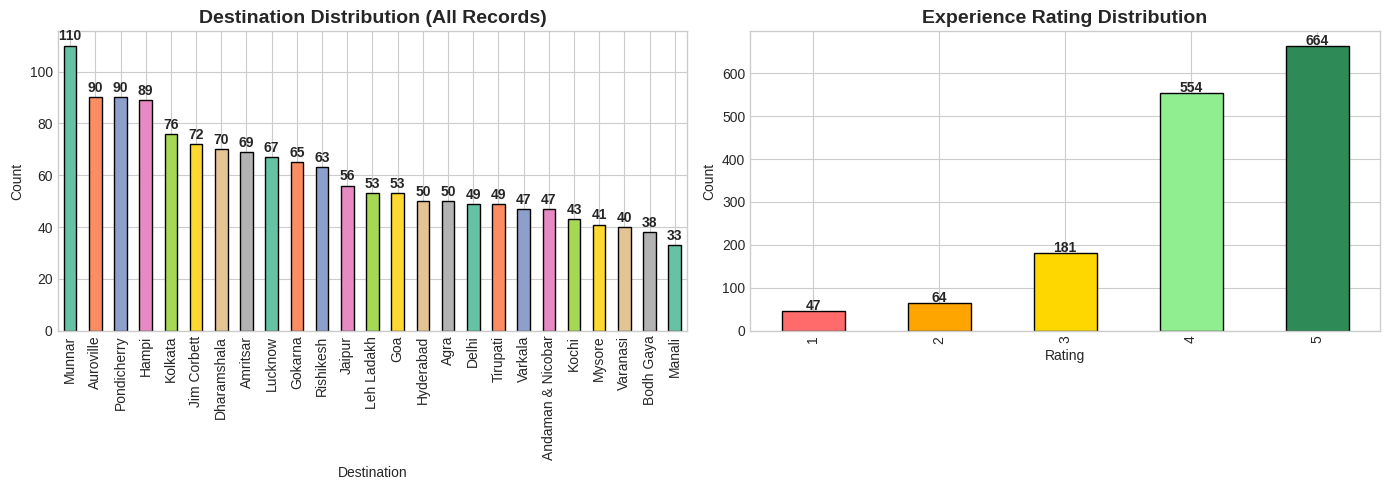


Total records: 1510
Unique destinations: 25
Experience rating range: 1 to 5


In [70]:
# Destination distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dest_counts = df['DestinationName'].value_counts()
dest_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(dest_counts)), edgecolor='black')
axes[0].set_title('Destination Distribution (All Records)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Destination')
for i, v in enumerate(dest_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Rating distribution
rating_counts = df['ExperienceRating'].value_counts().sort_index()
rating_counts.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#ffa500', '#ffd700', '#90ee90', '#2e8b57'], edgecolor='black')
axes[1].set_title('Experience Rating Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Rating')
for i, v in enumerate(rating_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal records: {len(df)}")
print(f"Unique destinations: {df['DestinationName'].nunique()}")
print(f"Experience rating range: {df['ExperienceRating'].min()} to {df['ExperienceRating'].max()}")


### 4.2 Feature Distributions


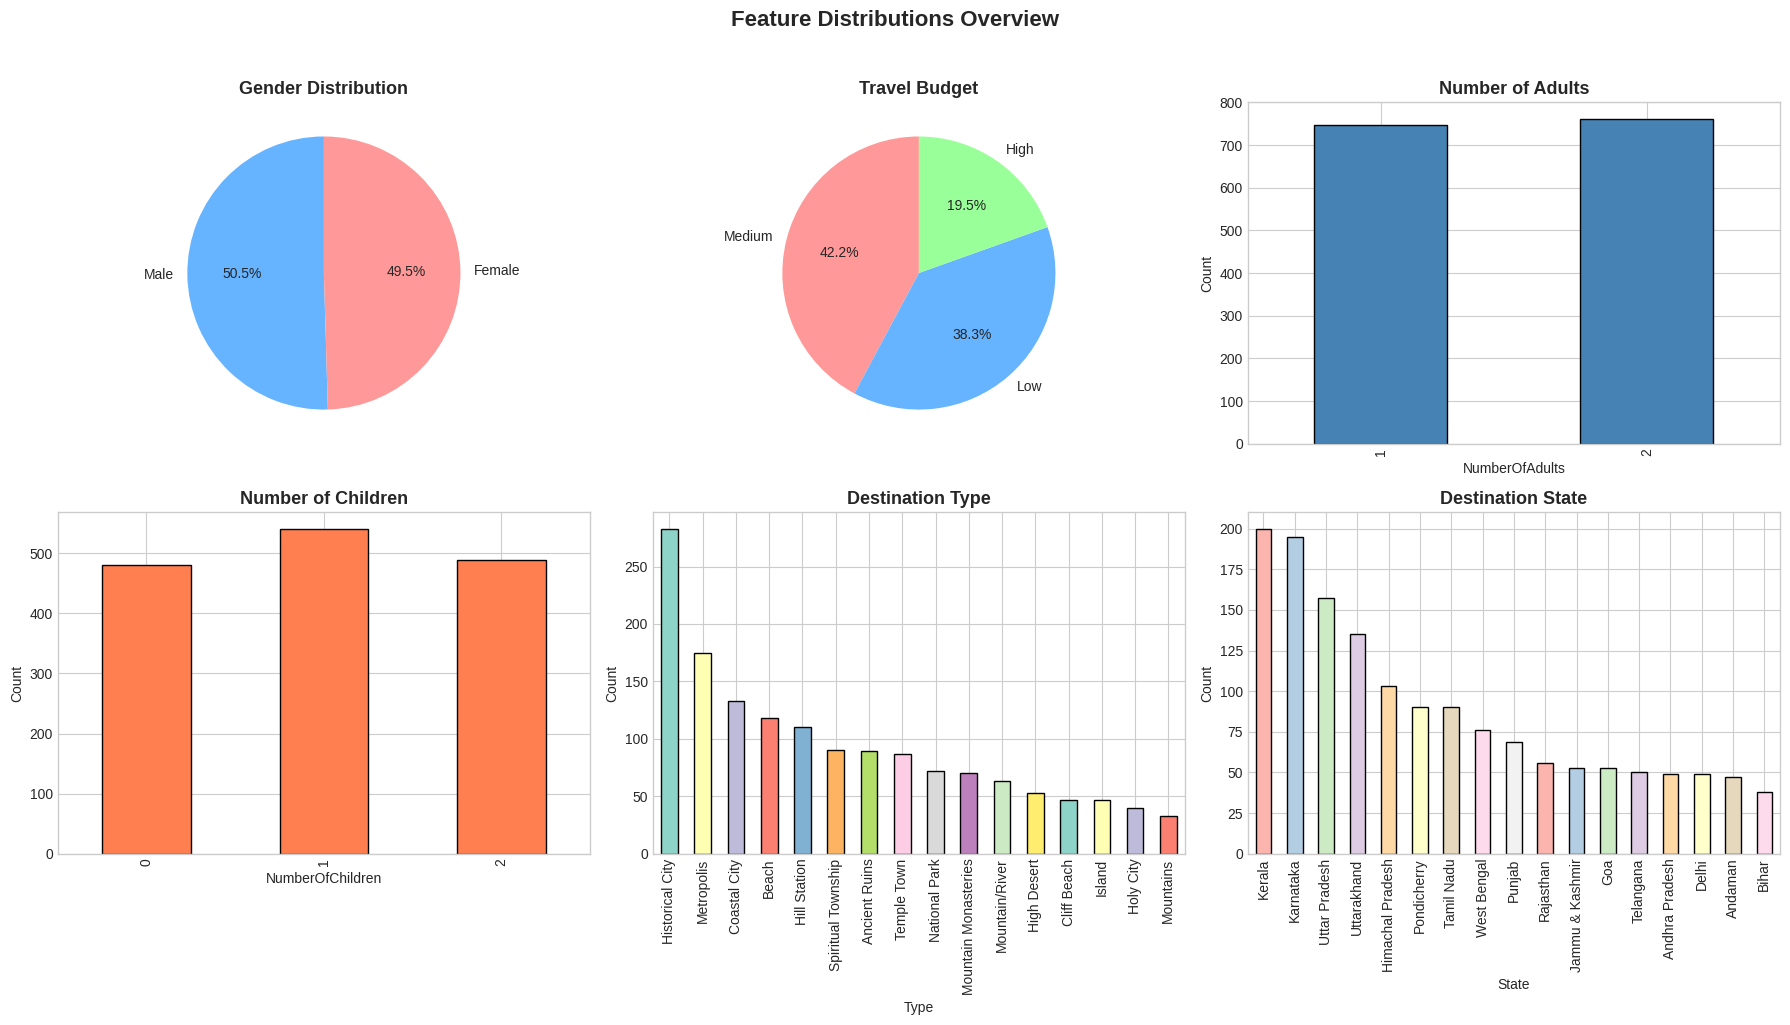

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gender
df['Gender'].value_counts().plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
axes[0,0].set_title('Gender Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('')

# Budget
df['Budget'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
axes[0,1].set_title('Travel Budget', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('')

# NumberOfAdults
df['NumberOfAdults'].value_counts().sort_index().plot(kind='bar', ax=axes[0,2], color='steelblue', edgecolor='black')
axes[0,2].set_title('Number of Adults', fontsize=13, fontweight='bold')
axes[0,2].set_ylabel('Count')

# NumberOfChildren
df['NumberOfChildren'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='coral', edgecolor='black')
axes[1,0].set_title('Number of Children', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Count')

# Type
df['Type'].value_counts().plot(kind='bar', ax=axes[1,1], color=sns.color_palette('Set3', df['Type'].nunique()), edgecolor='black')
axes[1,1].set_title('Destination Type', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Count')

# State
df['State'].value_counts().plot(kind='bar', ax=axes[1,2], color=sns.color_palette('Pastel1', df['State'].nunique()), edgecolor='black')
axes[1,2].set_title('Destination State', fontsize=13, fontweight='bold')
axes[1,2].set_ylabel('Count')

plt.suptitle('Feature Distributions Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.3 Feature vs Target Relationships


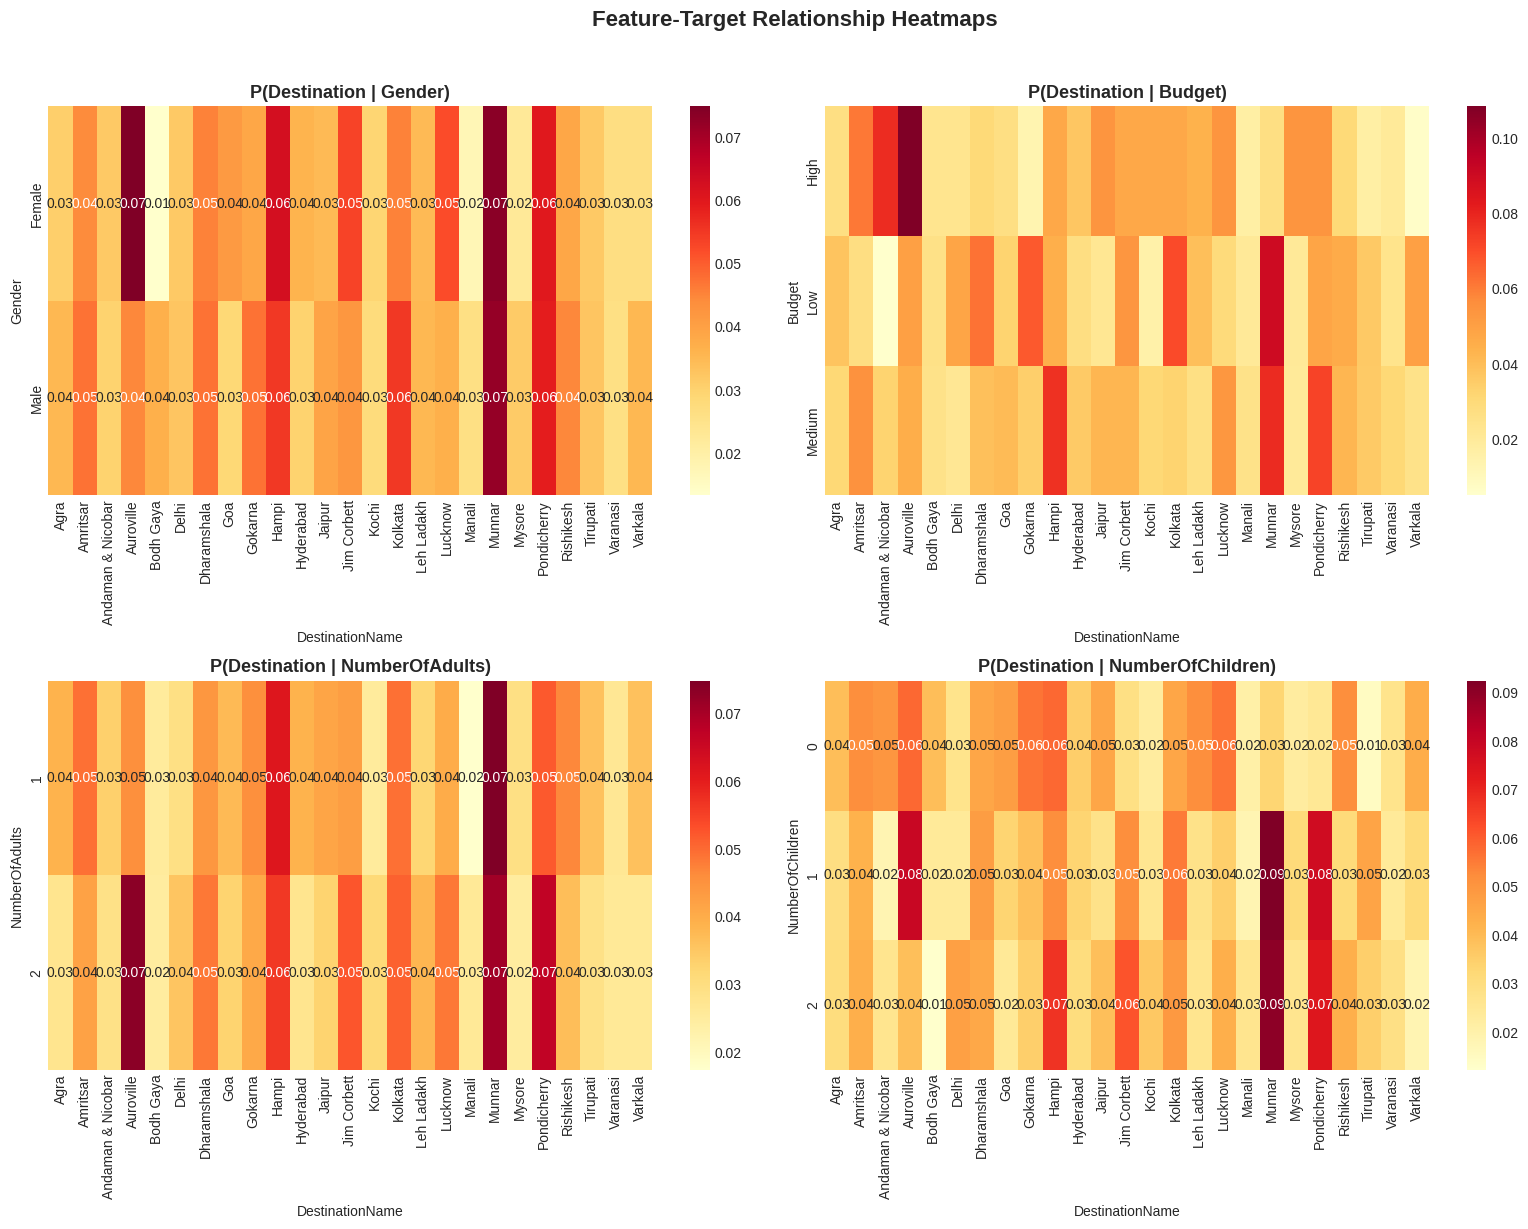

In [72]:
# Crosstab heatmaps: Which features are correlated with specific destinations?
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender vs Destination
ct_gender = pd.crosstab(df['Gender'], df['DestinationName'], normalize='index')
sns.heatmap(ct_gender, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0,0])
axes[0,0].set_title('P(Destination | Gender)', fontsize=13, fontweight='bold')

# Budget vs Destination
ct_budget = pd.crosstab(df['Budget'], df['DestinationName'], normalize='index')
sns.heatmap(ct_budget, annot=False, cmap='YlOrRd', ax=axes[0,1])
axes[0,1].set_title('P(Destination | Budget)', fontsize=13, fontweight='bold')

# NumberOfAdults vs Destination
ct_adults = pd.crosstab(df['NumberOfAdults'], df['DestinationName'], normalize='index')
sns.heatmap(ct_adults, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('P(Destination | NumberOfAdults)', fontsize=13, fontweight='bold')

# NumberOfChildren vs Destination
ct_children = pd.crosstab(df['NumberOfChildren'], df['DestinationName'], normalize='index')
sns.heatmap(ct_children, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('P(Destination | NumberOfChildren)', fontsize=13, fontweight='bold')

plt.suptitle('Feature-Target Relationship Heatmaps', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.4 Data Leakage Detection


In [73]:

# CRITICAL CHECK: Do destination-specific columns perfectly predict the target?
print("=" * 60)
print("  DATA LEAKAGE CHECK")
print("=" * 60)
print()

# State vs DestinationName
ct_state = pd.crosstab(df['State'], df['DestinationName'])
print("Crosstab: State vs DestinationName")
display(ct_state)
print()

# Type vs DestinationName
ct_type = pd.crosstab(df['Type'], df['DestinationName'])
print("Crosstab: Type vs DestinationName")
display(ct_type)
print()

print("⚠️  FINDING: 'State', 'Type', and 'BestTimeToVisit' are destination-level attributes.")
print("   Each State maps to exactly one DestinationName → DATA LEAKAGE.")
print("   BestTimeToVisit has near 1:1 mapping (5 seasons for 5 destinations).")
print("   Including them in X would cause the model to just memorize")
print("   these attributes instead of learning from user preferences.")
print()
print("   ✅ EXCLUDE: State, Type, BestTimeToVisit, Popularity")
print("   Only USER-provided inputs will be used as features.")


  DATA LEAKAGE CHECK

Crosstab: State vs DestinationName


DestinationName,Agra,Amritsar,Andaman & Nicobar,Auroville,Bodh Gaya,Delhi,Dharamshala,Goa,Gokarna,Hampi,...,Leh Ladakh,Lucknow,Manali,Munnar,Mysore,Pondicherry,Rishikesh,Tirupati,Varanasi,Varkala
State,,,,,,,,,,,,,,,,,,,,,
Andaman,0,0,47,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Andhra Pradesh,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,49,0,0
Bihar,0,0,0,0,38,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Delhi,0,0,0,0,0,49,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Goa,0,0,0,0,0,0,0,53,0,0,...,0,0,0,0,0,0,0,0,0,0
Himachal Pradesh,0,0,0,0,0,0,70,0,0,0,...,0,0,33,0,0,0,0,0,0,0
Jammu & Kashmir,0,0,0,0,0,0,0,0,0,0,...,53,0,0,0,0,0,0,0,0,0
Karnataka,0,0,0,0,0,0,0,0,65,89,...,0,0,0,0,41,0,0,0,0,0
Kerala,0,0,0,0,0,0,0,0,0,0,...,0,0,0,110,0,0,0,0,0,47



Crosstab: Type vs DestinationName


DestinationName,Agra,Amritsar,Andaman & Nicobar,Auroville,Bodh Gaya,Delhi,Dharamshala,Goa,Gokarna,Hampi,...,Leh Ladakh,Lucknow,Manali,Munnar,Mysore,Pondicherry,Rishikesh,Tirupati,Varanasi,Varkala
Type,,,,,,,,,,,,,,,,,,,,,
Ancient Ruins,0,0,0,0,0,0,0,0,0,89,...,0,0,0,0,0,0,0,0,0,0
Beach,0,0,0,0,0,0,0,53,65,0,...,0,0,0,0,0,0,0,0,0,0
Cliff Beach,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,47
Coastal City,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,90,0,0,0,0
High Desert,0,0,0,0,0,0,0,0,0,0,...,53,0,0,0,0,0,0,0,0,0
Hill Station,0,0,0,0,0,0,0,0,0,0,...,0,0,0,110,0,0,0,0,0,0
Historical City,50,69,0,0,0,0,0,0,0,0,...,0,67,0,0,41,0,0,0,0,0
Holy City,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,40,0
Island,0,0,47,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



⚠️  FINDING: 'State', 'Type', and 'BestTimeToVisit' are destination-level attributes.
   Each State maps to exactly one DestinationName → DATA LEAKAGE.
   BestTimeToVisit has near 1:1 mapping (5 seasons for 5 destinations).
   Including them in X would cause the model to just memorize
   these attributes instead of learning from user preferences.

   ✅ EXCLUDE: State, Type, BestTimeToVisit, Popularity
   Only USER-provided inputs will be used as features.


---
## Data Preparation & Feature Engineering


In [74]:
from sklearn.preprocessing import LabelEncoder

# Reliability Filtering — Only learn from HIGH SATISFACTION trips
df_clean = df[df['ExperienceRating'] >= 4].copy()
print(f"Records after ExperienceRating >= 4 filter: {len(df_clean)} (from {len(df)})")

# Target Variable — Label Encode DestinationName
le_dest = LabelEncoder()
df_clean['Target_Destination'] = le_dest.fit_transform(df_clean['DestinationName'])
n_classes = len(le_dest.classes_)

print(f"Number of classes: {n_classes}")
print("Class mapping:")
for i, name in enumerate(le_dest.classes_):
    count = (df_clean['Target_Destination'] == i).sum()
    print(f"   {i} → {name}  ({count} samples)")


Records after ExperienceRating >= 4 filter: 1218 (from 1510)
Number of classes: 25
Class mapping:
   0 → Agra  (38 samples)
   1 → Amritsar  (58 samples)
   2 → Andaman & Nicobar  (45 samples)
   3 → Auroville  (70 samples)
   4 → Bodh Gaya  (32 samples)
   5 → Delhi  (39 samples)
   6 → Dharamshala  (60 samples)
   7 → Goa  (45 samples)
   8 → Gokarna  (51 samples)
   9 → Hampi  (59 samples)
   10 → Hyderabad  (43 samples)
   11 → Jaipur  (43 samples)
   12 → Jim Corbett  (62 samples)
   13 → Kochi  (34 samples)
   14 → Kolkata  (67 samples)
   15 → Leh Ladakh  (46 samples)
   16 → Lucknow  (50 samples)
   17 → Manali  (26 samples)
   18 → Munnar  (86 samples)
   19 → Mysore  (32 samples)
   20 → Pondicherry  (76 samples)
   21 → Rishikesh  (43 samples)
   22 → Tirupati  (41 samples)
   23 → Varanasi  (32 samples)
   24 → Varkala  (40 samples)


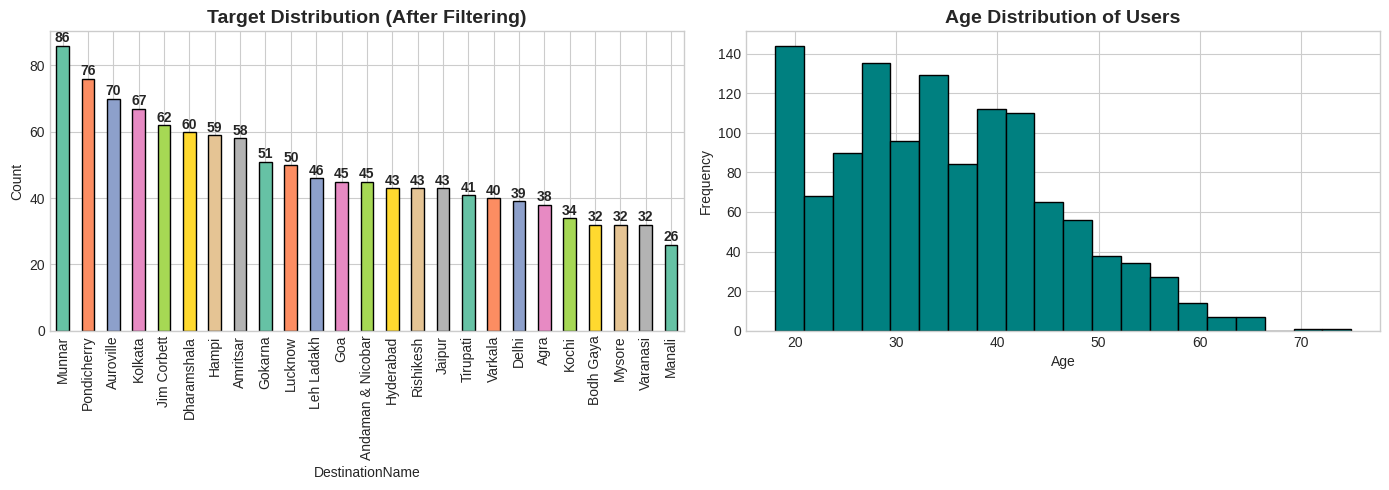

In [75]:
# Post-filter EDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution after filtering
df_clean['DestinationName'].value_counts().plot(
    kind='bar', ax=axes[0], 
    color=sns.color_palette('Set2', n_classes), edgecolor='black'
)
axes[0].set_title('Target Distribution (After Filtering)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(df_clean['DestinationName'].value_counts().values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Age distribution
df_clean['Age'].plot(
    kind='hist', bins=20, ax=axes[1], color='teal', edgecolor='black'
)
axes[1].set_title('Age Distribution of Users', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()


In [76]:
# Select features
# We ONLY use features that a REAL USER would provide as input:
#   - Gender            (user demographic)
#   - NumberOfAdults    (group composition)
#   - NumberOfChildren  (group composition)
#   - Pref_...          (one-hot encoded compound preference combinations)
#
# EXCLUDED (destination-level attributes = data leakage):
#   - State, Type, BestTimeToVisit, Popularity

numeric_features = ['Age', 'NumberOfAdults', 'NumberOfChildren', 'TravelMonth']
categorical_features = ['Gender', 'Budget', 'Pref_Relaxation', 'Pref_Adventure', 'Pref_Culture', 'Pref_Spiritual']

features = numeric_features + categorical_features
X = df_clean[features].copy()
y = df_clean['Target_Destination'].copy()

print(f"Selected features ({len(features)}): {features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()

# Compute class weights for imbalanced classes
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(zip(np.unique(y), class_weights))
print(f"Class weights: {class_weights}")

Selected features (10): ['Age', 'NumberOfAdults', 'NumberOfChildren', 'TravelMonth', 'Gender', 'Budget', 'Pref_Relaxation', 'Pref_Adventure', 'Pref_Culture', 'Pref_Spiritual']
X shape: (1218, 10)
y shape: (1218,)

Class weights: {np.int64(0): np.float64(1.2821052631578946), np.int64(1): np.float64(0.84), np.int64(2): np.float64(1.0826666666666667), np.int64(3): np.float64(0.696), np.int64(4): np.float64(1.5225), np.int64(5): np.float64(1.2492307692307691), np.int64(6): np.float64(0.812), np.int64(7): np.float64(1.0826666666666667), np.int64(8): np.float64(0.9552941176470588), np.int64(9): np.float64(0.8257627118644068), np.int64(10): np.float64(1.1330232558139535), np.int64(11): np.float64(1.1330232558139535), np.int64(12): np.float64(0.7858064516129032), np.int64(13): np.float64(1.4329411764705882), np.int64(14): np.float64(0.7271641791044776), np.int64(15): np.float64(1.0591304347826087), np.int64(16): np.float64(0.9744), np.int64(17): np.float64(1.873846153846154), np.int64(18): np.

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 80/20 stratified split
# IMPORTANT: Splitting BEFORE any encoding or scaling to prevent data leakage!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print()

# Verify stratification
print("Class distribution in train vs test:")
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for i in range(n_classes):
    print(f"   Class {i} ({le_dest.classes_[i]}): Train={train_dist.get(i, 0):.3f}  Test={test_dist.get(i, 0):.3f}")

# Define the ColumnTransformer Pipeline
# Scale ONLY the numeric features
# One-Hot Encode categorical features (ignore unknown categories in production!)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# For Tree models, we don't scale the numeric features!
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])


Training set: (974, 10)
Testing set:  (244, 10)

Class distribution in train vs test:
   Class 0 (Agra): Train=0.031  Test=0.033
   Class 1 (Amritsar): Train=0.047  Test=0.049
   Class 2 (Andaman & Nicobar): Train=0.037  Test=0.037
   Class 3 (Auroville): Train=0.057  Test=0.057
   Class 4 (Bodh Gaya): Train=0.027  Test=0.025
   Class 5 (Delhi): Train=0.032  Test=0.033
   Class 6 (Dharamshala): Train=0.049  Test=0.049
   Class 7 (Goa): Train=0.037  Test=0.037
   Class 8 (Gokarna): Train=0.042  Test=0.041
   Class 9 (Hampi): Train=0.048  Test=0.049
   Class 10 (Hyderabad): Train=0.035  Test=0.037
   Class 11 (Jaipur): Train=0.035  Test=0.037
   Class 12 (Jim Corbett): Train=0.051  Test=0.049
   Class 13 (Kochi): Train=0.028  Test=0.029
   Class 14 (Kolkata): Train=0.054  Test=0.057
   Class 15 (Leh Ladakh): Train=0.038  Test=0.037
   Class 16 (Lucknow): Train=0.041  Test=0.041
   Class 17 (Manali): Train=0.022  Test=0.020
   Class 18 (Munnar): Train=0.071  Test=0.070
   Class 19 (Mysore

---
## Evaluation Framework


In [78]:
def evaluate_multiclass(name, model, y_true, y_pred, y_prob=None, is_keras_nn=False, cv_model=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Cross-validation (5-fold)
    cv_mean_str = "N/A (Keras)"
    cv_mean_val = 0.0
    if not is_keras_nn:
        try:
            cv_blueprint = clone(cv_model) if cv_model is not None else clone(model)
            cv_scores = cross_val_score(cv_blueprint, X_train, y_train, cv=5, scoring='f1_weighted')
            cv_mean_val = cv_scores.mean()
            cv_mean_str = f"{cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})"
        except Exception as e:
            cv_mean_str = f"Error: {e}"
            
    # Top-3 Accuracy
    top3_acc = 0.0
    if y_prob is not None and y_prob.shape[1] >= 3:
        top3_preds = np.argsort(y_prob, axis=1)[:, -3:]
        top3_acc = np.array([y_true.iloc[i] in top3_preds[i] for i in range(len(y_true))]).mean()
    
    # BLOCK 9: INITIAL OUTPUT BEFORE MENU
    print("\n===== INITIAL MODEL RESULTS =====")
    print("Model Accuracy:", round(acc, 4))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=le_dest.classes_, yticklabels=le_dest.classes_,
                annot_kws={"size": 8})
    plt.title(f"Confusion Matrix - {name}", fontsize=15, fontweight='bold')
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Store results
    results[name] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Top3-Acc': round(top3_acc, 4),
        'CV-F1': round(cv_mean_val, 4) if not is_keras_nn else 0.0
    }
    all_predictions[name] = y_pred

# Initialize global dictionaries for results
results = {}
all_predictions = {}


===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.25
Confusion Matrix:
[[0 2 0 0 0 2 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0]
 [2 1 0 0 0 1 0 0 0 0 0 0 0 3 0 0 2 0 0 2 0 0 0 1 0]
 [0 0 8 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 8 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0]
 [0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 1 0 1 0 2 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 3 4 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0]
 [0 0 3 0 0 0 0 3 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 2 0 0 1 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3]
 [0 0 0 0 0 2 0 0 0 1 0 1 0 2 3 0 2 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 3 2 0 1 0 0 2 0 0 0 0 0]
 [1 3 0 0 0 2 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 3 0 0 4 0 2 2 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 2 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 1 1 0 2 0 3 3 0 0 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 3 0 2 0 0 0 2 0 0 0]
 [0 0 0 1 0 1 0 0 0 1 1 2 0 2 0 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0

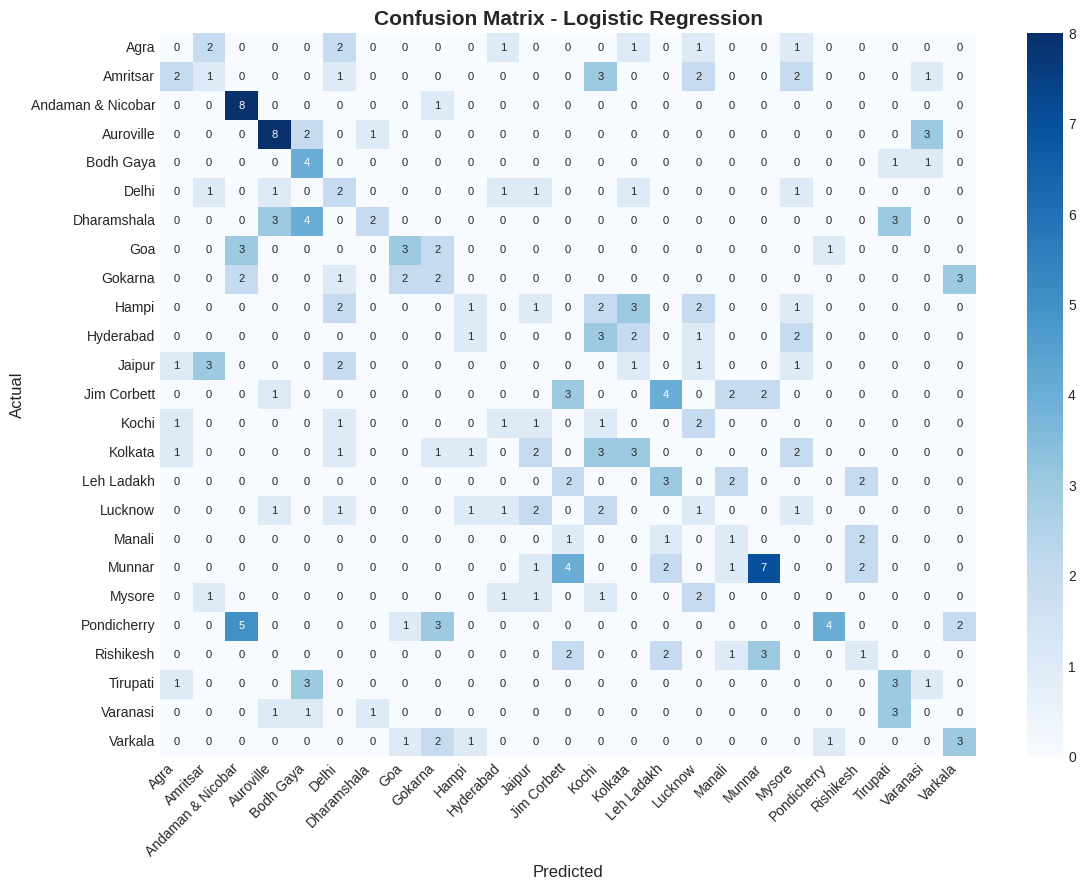

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Logistic Regression (Multinomial)
log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(
        multi_class='multinomial', solver='lbfgs', random_state=42, 
        max_iter=2000, class_weight=class_weights, C=1.0
    ))
])
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)

evaluate_multiclass("Logistic Regression", log_reg, y_test, y_pred_lr, y_prob_lr)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2008
Confusion Matrix:
[[0 2 0 0 0 2 0 0 0 0 1 0 0 0 0 0 1 0 0 2 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 1 1 0 0 2 0 0 2 0 0 3 0 0 0 1 0]
 [0 0 5 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0]
 [0 0 0 4 4 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0]
 [0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 0]
 [0 1 0 0 0 2 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 5 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 5 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
 [0 0 5 0 0 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2]
 [0 1 0 0 0 2 0 0 0 2 0 1 0 2 2 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 5 0 0 1 0 0 2 0 0 0 0 0]
 [1 2 0 0 0 2 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 4 0 2 4 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 2 1 0 0 0 0 0 2 0 0 0 0 0 0 0 0]
 [2 1 0 0 0 1 0 0 1 1 0 1 0 2 2 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 3 0 2 0 0 0 2 0 0 0]
 [0 1 0 0 0 1 0 0 0 1 0 2 0 1 0 0 1 0 0 2 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0

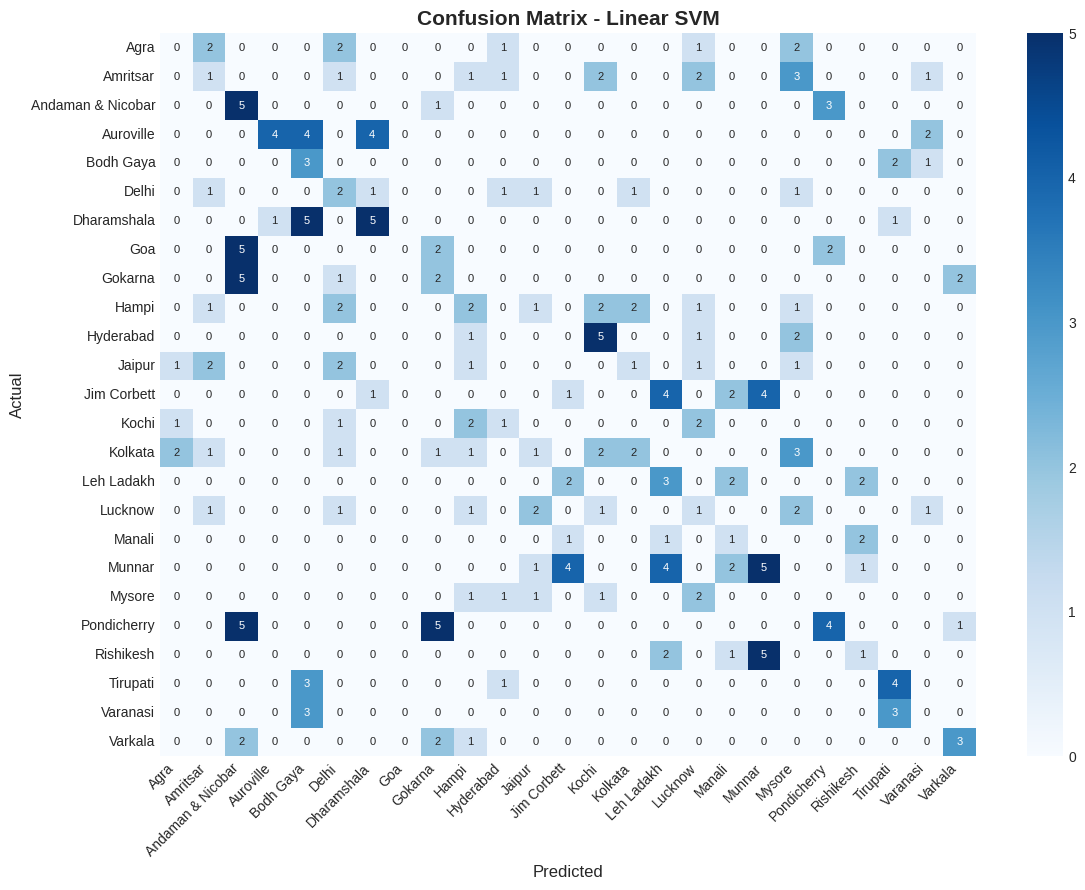

In [80]:
from sklearn.svm import SVC

# Linear SVM (One-vs-Rest)
svm_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(
        kernel='linear', probability=True, decision_function_shape='ovr', 
        random_state=42, class_weight=class_weights
    ))
])
svm_linear.fit(X_train, y_train)

y_pred_svm_lin = svm_linear.predict(X_test)
y_prob_svm_lin = svm_linear.predict_proba(X_test)

evaluate_multiclass("Linear SVM", svm_linear, y_test, y_pred_svm_lin, y_prob_svm_lin)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2418
Confusion Matrix:
[[ 0  1  0  0  0  1  0  0  0  0  1  0  0  1  4  0  0  0  0  0  0  0  0  0
   0]
 [ 1  0  0  0  0  0  0  0  0  1  0  0  0  5  4  0  0  0  0  0  0  0  1  0
   0]
 [ 0  0  1  0  0  0  0  2  1  0  0  0  0  0  0  0  0  0  0  0  5  0  0  0
   0]
 [ 0  0  0  1  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0
   0]
 [ 0  0  0  0  2  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0
   0]
 [ 0  1  0  0  0  0  1  0  0  0  0  0  0  0  6  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0
   0]
 [ 0  0  0  0  0  0  0  3  2  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0
   0]
 [ 0  0  0  0  0  1  0  2  3  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0
   3]
 [ 0  1  0  0  0  0  0  0  0  2  0  0  0  2  7  0  0  0  0  0  0  0  0  0
   0]
 [ 0  1  0  0  0  0  0  0  0  0  1  0  0  3  4  0  0  0  0  0  0  0  0  0
   0]
 [ 0  2  0  0  0  0  0  0  0  2  0  0  0  0 

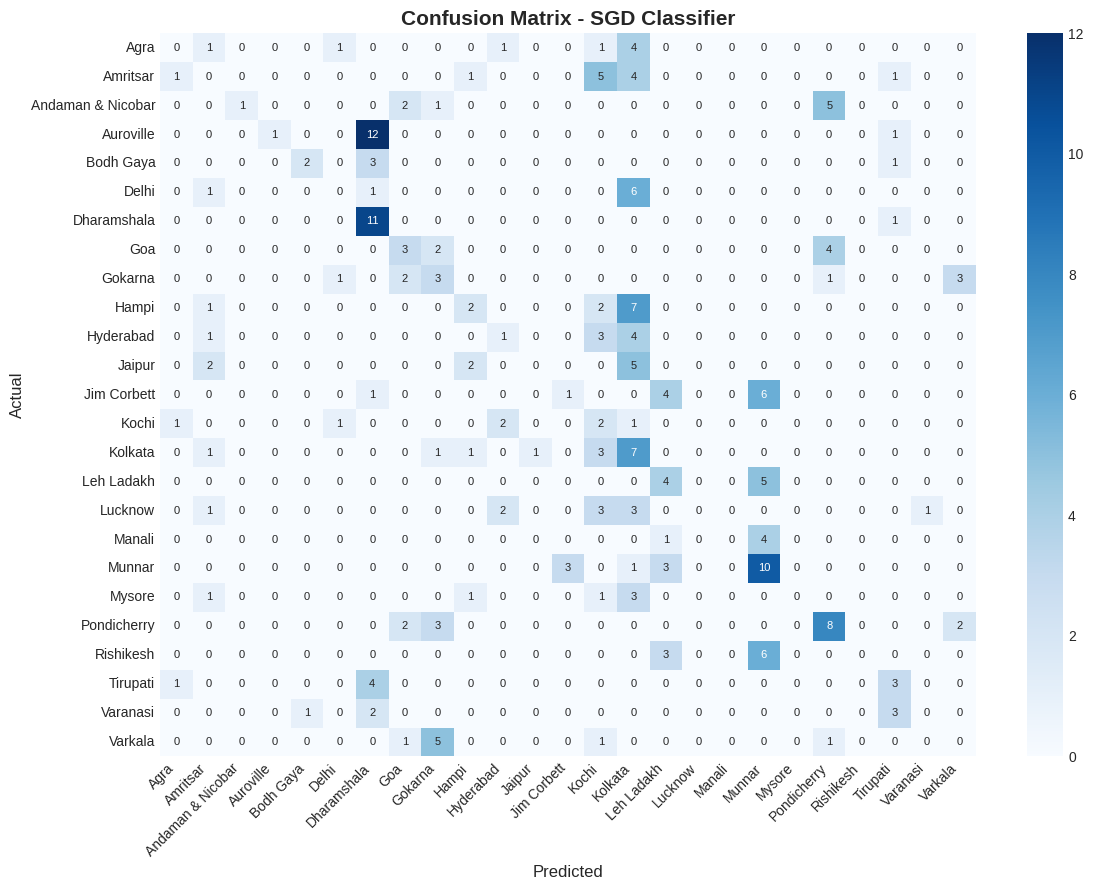

In [81]:
from sklearn.linear_model import SGDClassifier

# Stochastic Gradient Descent (SGD)
sgd = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SGDClassifier(
        loss='log_loss', random_state=42, max_iter=1000, 
        class_weight=class_weights, alpha=0.0001
    ))
])
sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)
y_prob_sgd = sgd.predict_proba(X_test)

evaluate_multiclass("SGD Classifier", sgd, y_test, y_pred_sgd, y_prob_sgd)


---
## Non-Linear Classifiers



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2336
Confusion Matrix:
[[1 2 0 0 0 0 0 0 0 0 0 1 0 0 4 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 1 0 0 0 2 0 1 0 1 3 0 1 0 0 0 0 0 1 0 0]
 [0 0 6 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
 [0 0 0 8 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 2 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 0 2 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 4 1 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 1]
 [0 0 3 0 0 0 0 2 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 2]
 [1 2 0 0 0 2 0 0 0 0 3 0 0 0 4 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 2 0 0 0 1 0 1 0 0 3 0 1 0 0 0 0 0 0 0 0]
 [2 3 0 0 0 2 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 3 0 0 3 0 0 5 0 0 0 0 0 0]
 [1 1 0 0 0 1 0 0 0 2 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [2 5 0 0 0 2 0 0 1 0 0 1 0 1 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 1 0 0 6 0 0 0 0 0 0]
 [0 5 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0

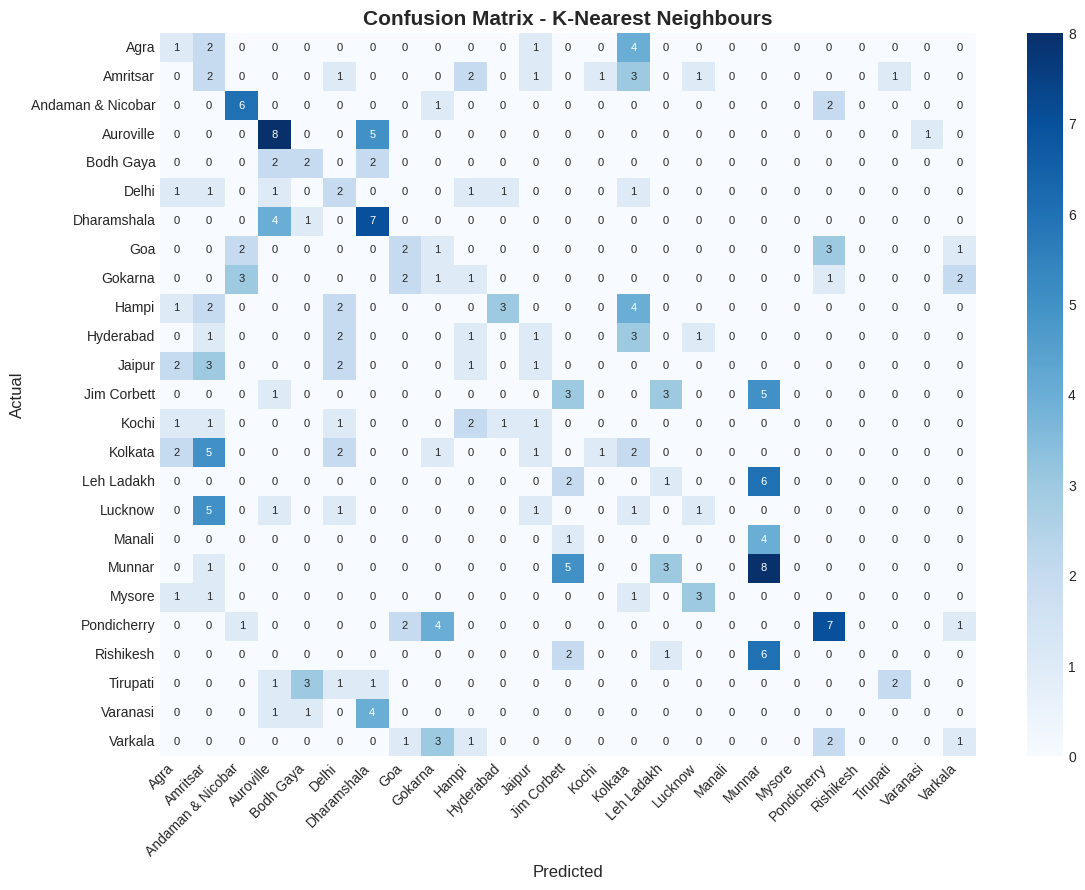

In [82]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# K-Nearest Neighbours
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier())
])

param_grid_knn = {
    'clf__n_neighbors': list(range(1, 31)),
    'clf__weights': ['uniform', 'distance'],
    'clf__p': [1, 2]
}

grid_knn = GridSearchCV(
    pipe_knn, param_grid=param_grid_knn, cv=5, scoring="f1_weighted", n_jobs=-1
)
grid_knn.fit(X_train, y_train)

knn = grid_knn.best_estimator_
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)

evaluate_multiclass("K-Nearest Neighbours", knn, y_test, y_pred_knn, y_prob_knn)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.209
Confusion Matrix:
[[0 1 0 0 0 0 0 0 0 1 1 0 0 1 2 0 0 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 2 1 0 2 0 0 4 0 0 0 1 0]
 [0 0 8 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 4 4 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0]
 [0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 2 1 0 0 0 1 0 0 0 1 0 0 0 0 2 0 0 0 0 0]
 [0 0 0 1 3 0 7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 4 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 3 0 0 0 0 2 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 3]
 [1 2 0 0 0 2 0 0 0 1 0 0 0 2 1 0 2 0 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 3 0 0 1 0 0 4 0 0 0 0 0]
 [0 2 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 2 0 0 4 0 0 3 0 0 2 0 0 0]
 [0 1 0 0 0 0 0 0 0 1 3 0 0 0 0 0 2 0 0 0 0 0 0 0 0]
 [2 2 0 0 0 1 0 0 1 0 1 0 0 2 1 0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 3 1 0 0 2 0 0 0]
 [0 2 0 1 0 1 0 0 0 0 0 2 0 1 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 

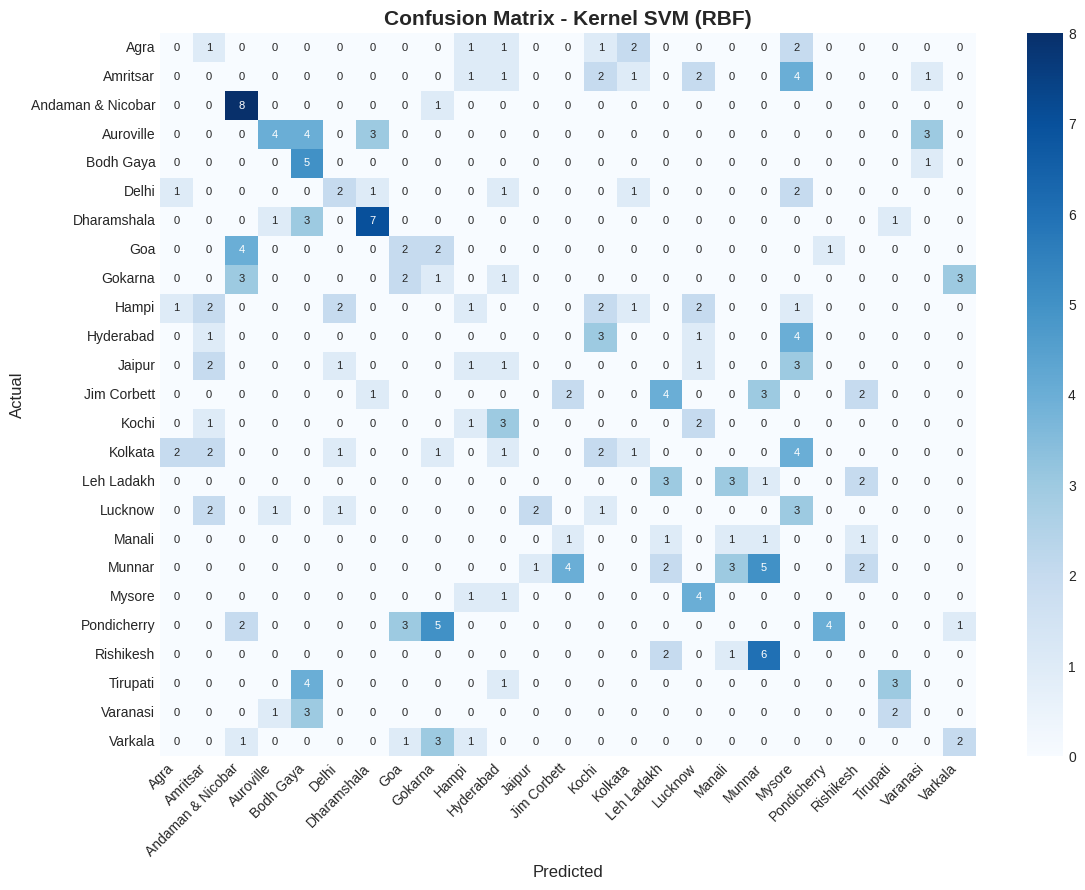

In [83]:
# Kernel SVM
svm_rbf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(
        kernel='rbf', probability=True, decision_function_shape='ovr', 
        random_state=42, class_weight=class_weights, gamma='scale'
    ))
])
svm_rbf.fit(X_train, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test)
y_prob_svm_rbf = svm_rbf.predict_proba(X_test)

evaluate_multiclass("Kernel SVM (RBF)", svm_rbf, y_test, y_pred_svm_rbf, y_prob_svm_rbf)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2172
Confusion Matrix:
[[ 0  4  0  0  0  2  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  1  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  1
   0]
 [ 0  0  8  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 10  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3
   0]
 [ 0  0  0  2  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
   0]
 [ 0  2  0  1  0  1  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  8  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
   0]
 [ 0  0  4  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  5  0  0  1  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  1  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0
   0]
 [ 0  5  0  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0
   0]
 [ 0  4  0  0  0  2  0  0  0  0  0  0  0  0 

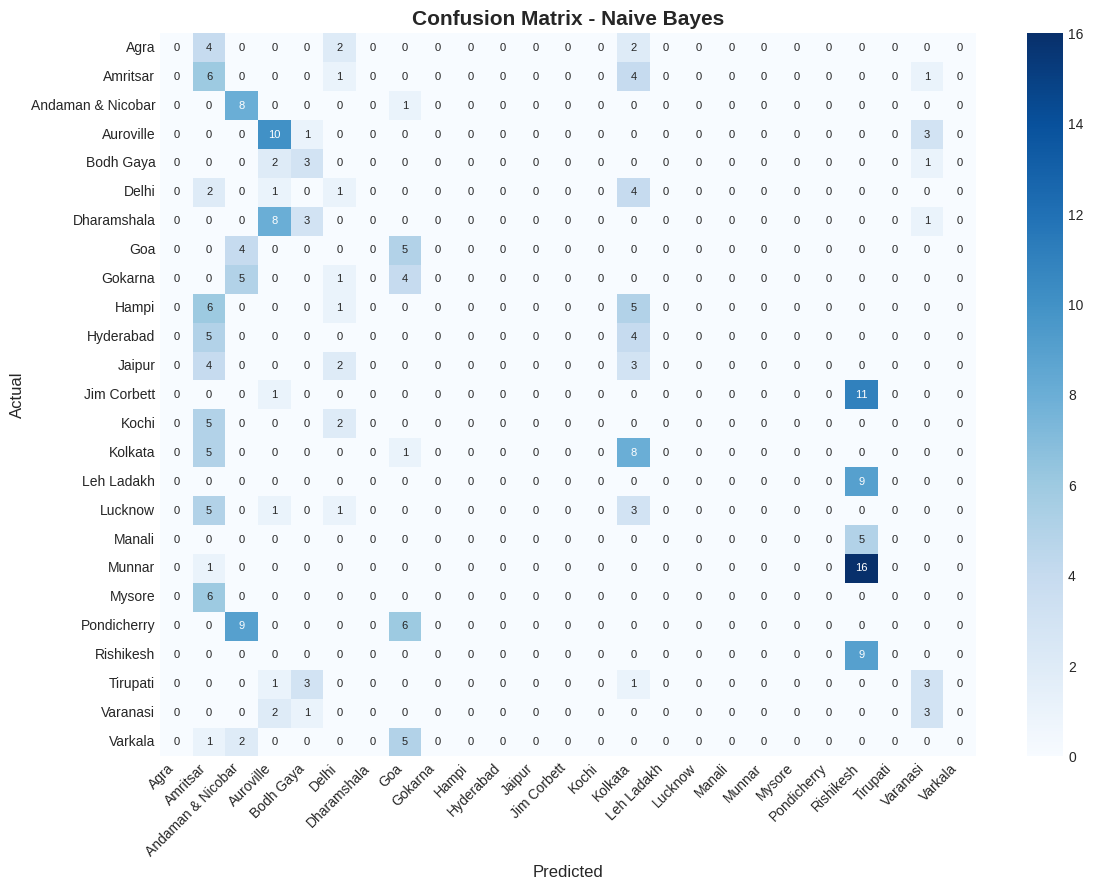

In [84]:
from sklearn.naive_bayes import GaussianNB

# Naive Bayes
nb = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', GaussianNB())
])
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)

evaluate_multiclass("Naive Bayes", nb, y_test, y_pred_nb, y_prob_nb)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.1926
Confusion Matrix:
[[1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 2 0 0 2 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 3 0 2 0 2 1 0 1 0 0 0 0 0 1 0 0]
 [0 0 2 0 0 0 0 1 2 0 0 0 0 0 0 0 0 1 0 0 3 0 0 0 0]
 [0 0 0 6 1 0 4 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 2 0 0]
 [0 0 0 0 1 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0]
 [1 2 0 0 0 2 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 2 4 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 2 0]
 [0 0 3 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
 [0 0 2 0 0 1 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 1 0 0 0 1 1 0 0 1 3 0 1 0 0 3 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 0 1 0 1 3 0 1 0 0 1 0 0 0 0 0]
 [3 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 3 0 0 6 0 1 1 0 0 0 0 0 0]
 [0 1 0 0 0 2 0 0 0 3 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 1 0 2 0 0 3 1 0 1 0 0 5 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 4 0 0 2 0 0 1 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 1 0 0 3 0 0 2 0 0 1 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0

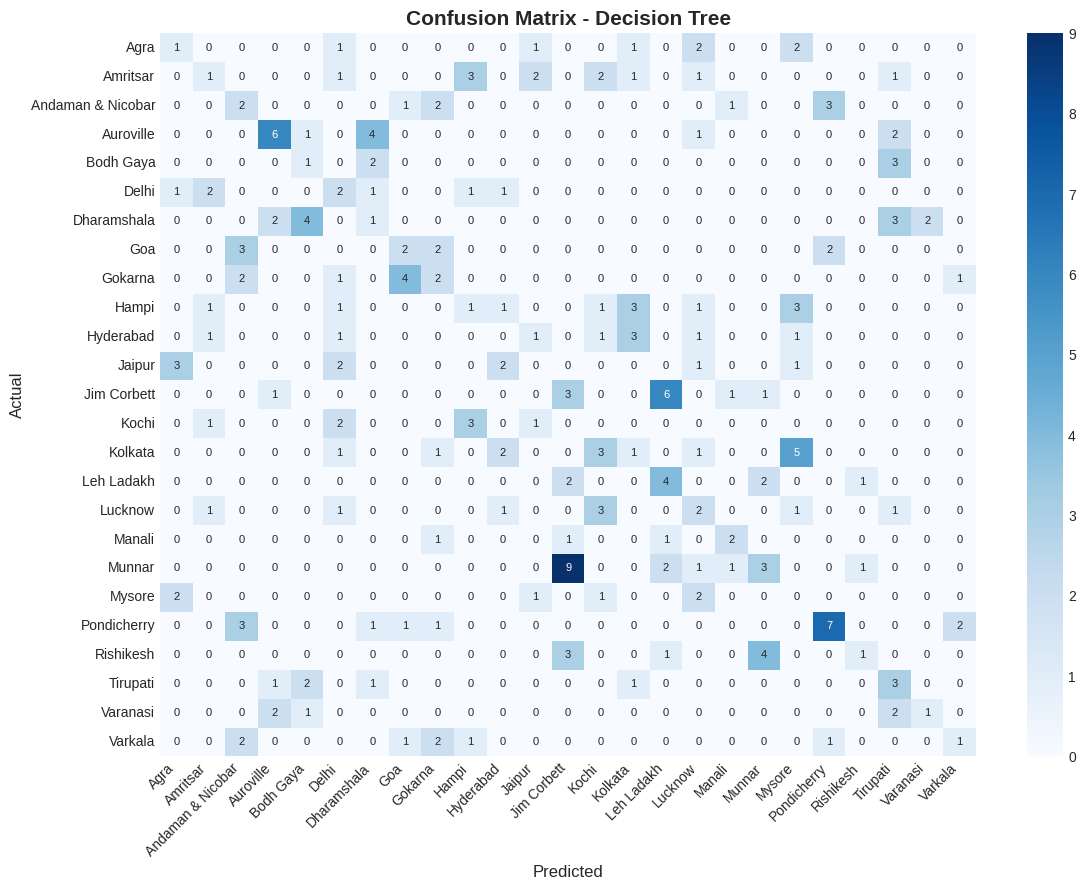

In [85]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree
dt = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', DecisionTreeClassifier(random_state=42, class_weight=class_weights, max_depth=10))
])
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)

evaluate_multiclass("Decision Tree", dt, y_test, y_pred_dt, y_prob_dt)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2336
Confusion Matrix:
[[0 0 0 0 0 2 0 0 0 0 0 1 0 0 2 0 1 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 1 0 2 3 0 1 0 0 3 0 0 0 1 0]
 [0 0 7 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 8 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 0]
 [0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 0 0 1 0 2 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 5 2 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 3 4 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 3 0 0 0 0 2 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 3]
 [1 0 0 0 0 1 0 0 0 1 1 0 0 2 2 0 1 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 3 0 3 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 3 0 0 0 0 2 1 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 4 0 3 4 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 1 2 1 0 0 0 0 1 0 0 1 0 0 0 0 0]
 [1 2 0 0 0 0 0 0 1 2 1 0 0 2 5 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0 0 3 0 0 3 0 0 0]
 [0 3 0 1 0 1 0 0 0 0 0 1 0 2 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0

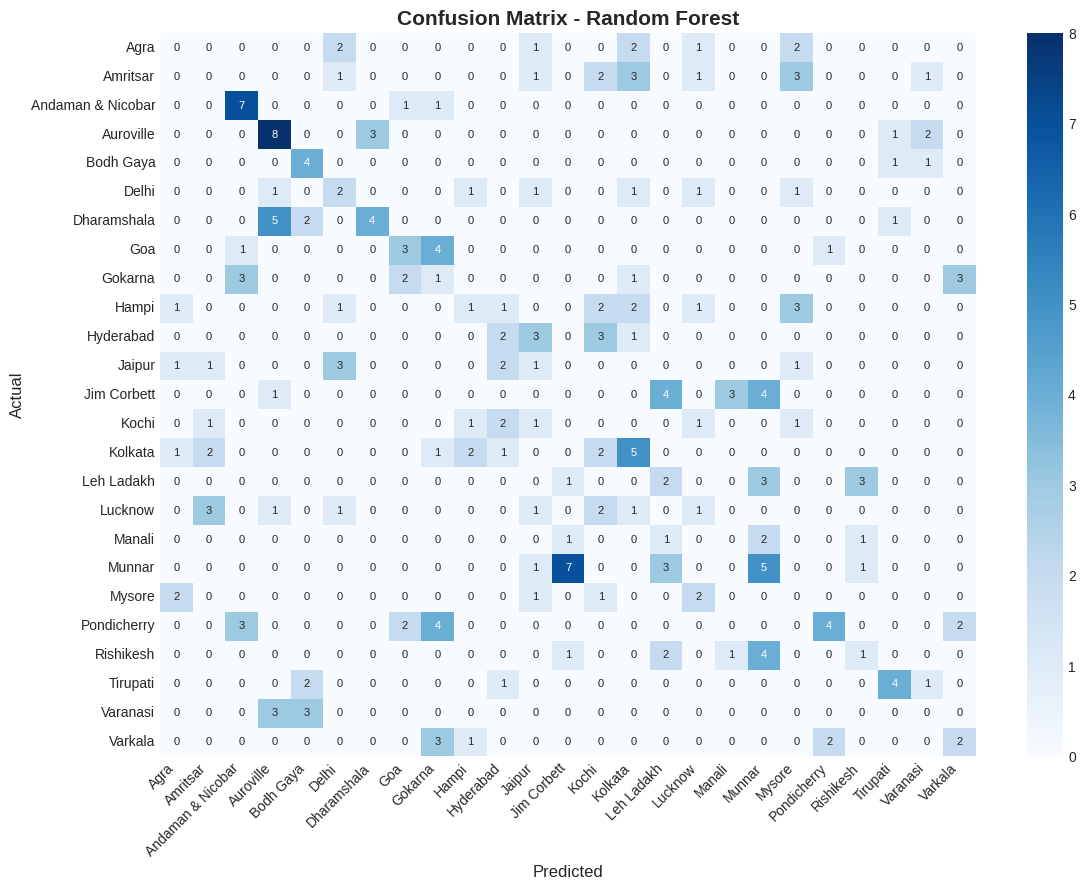

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Random Forest with Hyperparameter Tuning
pipe_rf = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', RandomForestClassifier(
        random_state=42, class_weight=class_weights
    ))
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 15, None],
    'clf__max_features': ['sqrt', 'log2', None],
    'clf__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    pipe_rf, param_grid=param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

rf = grid_rf.best_estimator_
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

evaluate_multiclass("Random Forest", rf, y_test, y_pred_rf, y_prob_rf, cv_model=grid_rf.best_estimator_)

---
## Ensemble & Neural Networks



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2213
Confusion Matrix:
[[ 0  7  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  9  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  1
   0]
 [ 0  0  4  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0
   2]
 [ 0  0  0  4  3  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0
   0]
 [ 0  0  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  3
   0]
 [ 0  6  0  0  0  0  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  5  0  0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0
   0]
 [ 0  0  4  0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0
   0]
 [ 0  0  4  0  0  0  0  4  0  0  1  0  0  0  0  0  0  0  0  0  1  0  0  0
   0]
 [ 0  8  0  0  0  0  0  0  0  0  1  0  0  3  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  5  0  0  0  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  0  0  0  0  0  2  0  0  1 

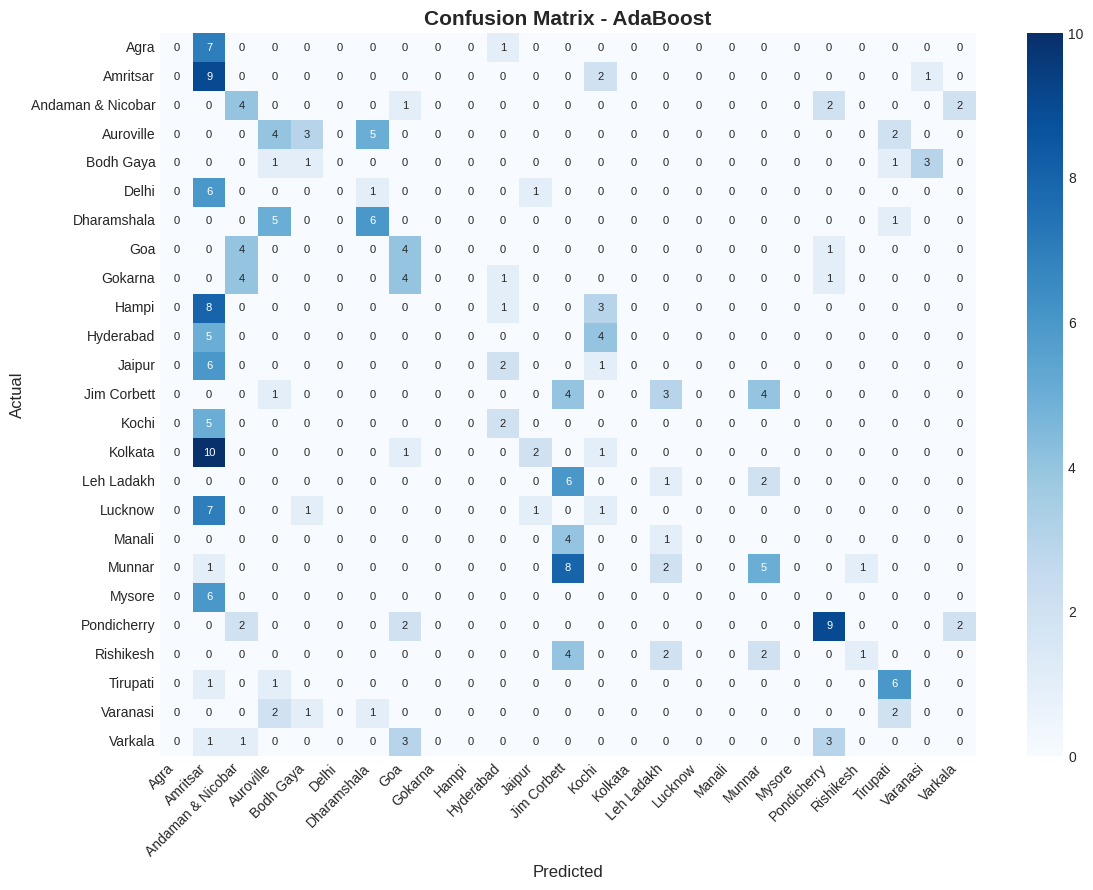

In [87]:
from sklearn.ensemble import AdaBoostClassifier

# AdaBoost
ada = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, class_weight=class_weights),
        random_state=42
    ))
])
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)
evaluate_multiclass("AdaBoost", ada, y_test, y_pred_ada, y_prob_ada)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2254
Confusion Matrix:
[[1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 2 0 0 2 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 2 1 1 0 2 3 0 0 0 0 1 0 0 0 1 0]
 [0 0 3 0 0 0 0 1 3 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
 [0 0 0 4 1 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 0]
 [0 0 0 1 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 1 0 0 0 0 1 0 0 1 0 1 0 1 2 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 7 0 0 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 1]
 [0 0 0 0 0 0 0 3 3 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 2]
 [0 2 0 0 0 1 0 0 0 3 1 0 0 1 3 0 0 0 0 1 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 1 2 3 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 1 0 0 0 1 3 0 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 2 0 0 3 0 1 4 0 0 1 0 0 0]
 [0 2 0 0 0 0 0 0 0 3 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [1 3 0 0 0 0 0 0 1 2 1 0 0 1 5 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 3 1 0 3 0 0 1 0 0 0]
 [1 2 0 1 0 0 0 0 0 0 0 2 0 0 2 0 2 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0

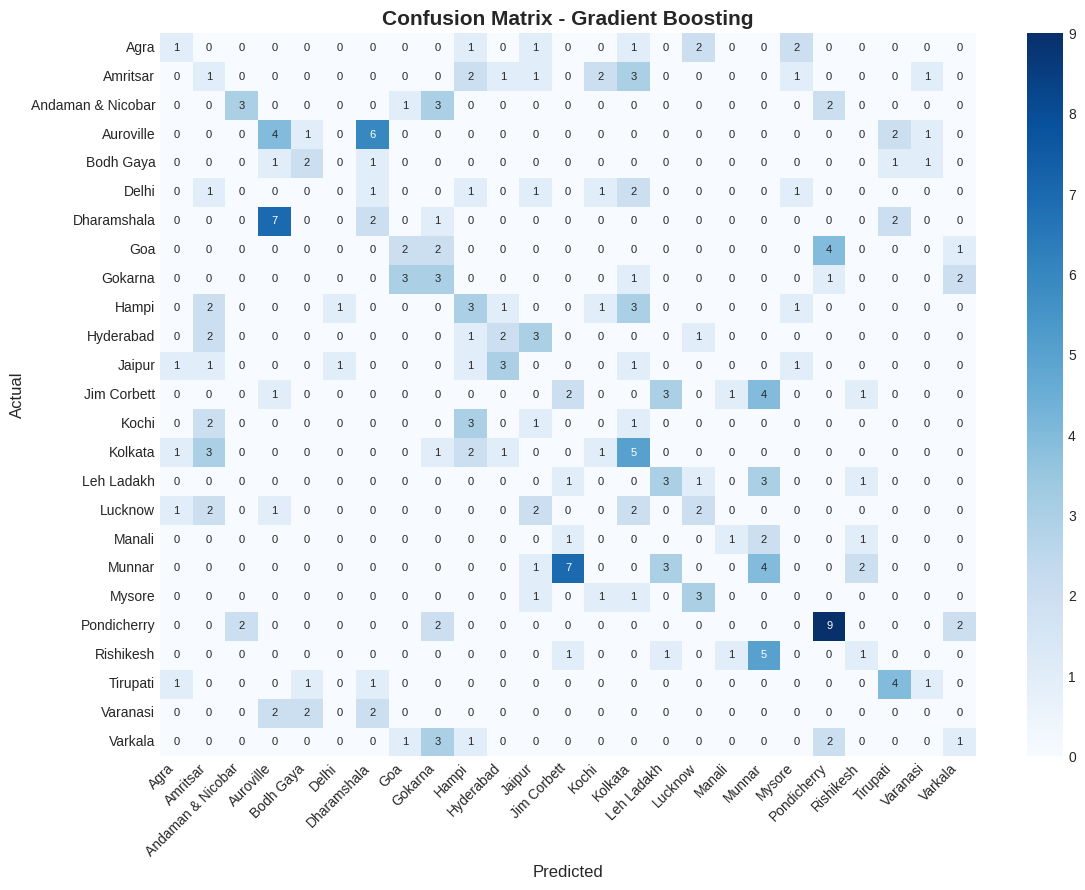

In [88]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting
gb = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', GradientBoostingClassifier(random_state=42))
])
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)
evaluate_multiclass("Gradient Boosting", gb, y_test, y_pred_gb, y_prob_gb)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2254
Confusion Matrix:
[[1 1 0 0 0 0 0 0 0 1 0 2 0 0 1 0 0 0 0 2 0 0 0 0 0]
 [1 2 0 0 0 0 0 0 0 3 0 1 0 2 1 0 1 0 0 0 0 0 1 0 0]
 [0 0 4 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 6 1 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0]
 [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 1 0]
 [1 1 0 1 0 2 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0]
 [0 0 0 8 0 0 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 2 3 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 1]
 [0 0 1 0 0 0 0 3 3 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1]
 [1 1 0 0 0 1 0 0 0 3 1 0 0 0 3 0 1 0 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 2 3 0 0 2 0 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 2 0 0 0 0 4 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 3 0 2 5 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 4 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 1 3 2 0 0 1 5 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0 1 2 0 0 3 0 0 0]
 [1 2 0 1 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0

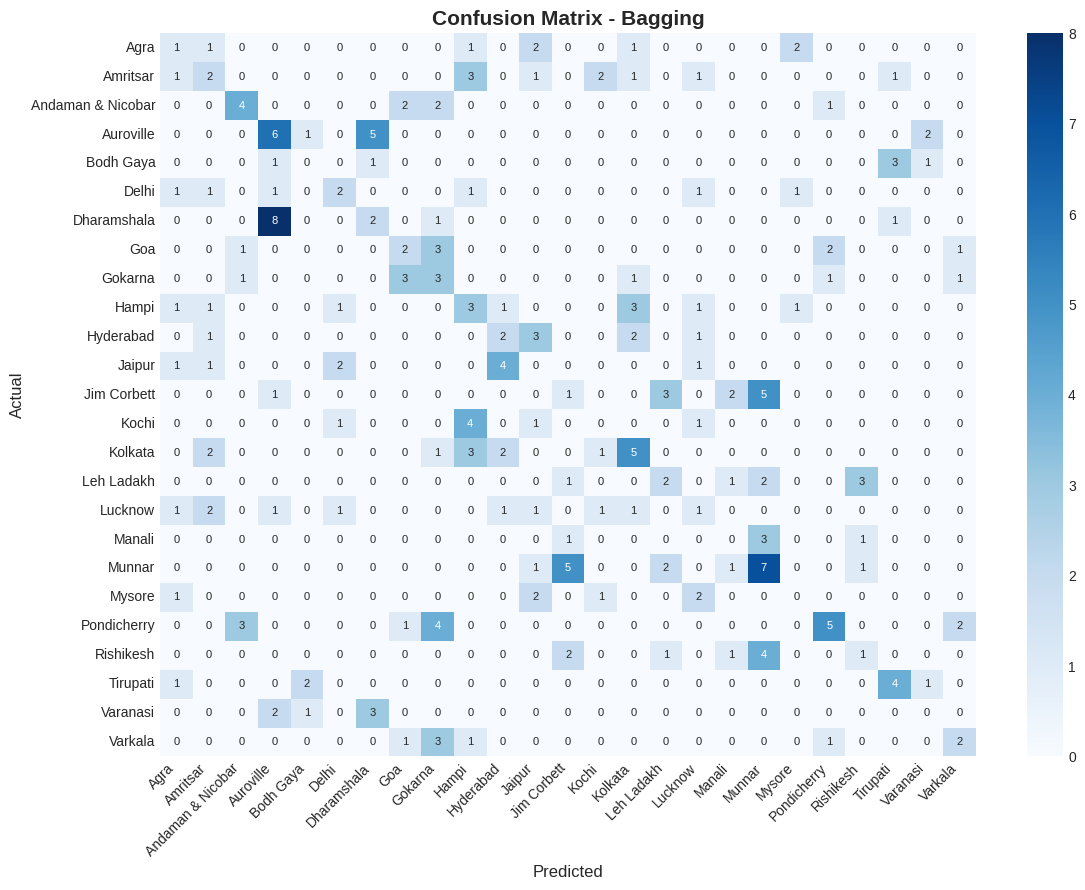

In [89]:
from sklearn.ensemble import BaggingClassifier

# Bagging
bagging = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('clf', BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10, class_weight=class_weights),
        n_estimators=200, max_samples=0.8, max_features=0.8,
        random_state=42, n_jobs=-1
    ))
])
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
y_prob_bag = bagging.predict_proba(X_test)
evaluate_multiclass("Bagging", bagging, y_test, y_pred_bag, y_prob_bag)



===== INITIAL MODEL RESULTS =====
Model Accuracy: 0.2295
Confusion Matrix:
[[2 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 3 0 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 2 0 0 4 0 0 1 0 0]
 [0 0 5 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 9 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 1 0 2 0 0 0 0 0 1 0 1 0 0 1 0 0 2 0 0 0 0 0]
 [0 0 0 5 2 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0]
 [0 0 2 0 0 0 0 3 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2]
 [0 0 2 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 2 0 0 0 3]
 [0 0 0 0 0 1 0 0 0 2 0 0 0 3 1 0 1 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 4 0 0 2 0 0 2 0 0 0 0 0]
 [1 0 0 0 0 3 0 0 0 0 1 2 0 0 0 0 0 0 0 2 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 5 0 1 4 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 2 1 0 6 0 0 1 0 0 2 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 3 0 0 4 0 0 1 0 0 0]
 [1 0 0 0 0 0 1 0 0 0 2 1 0 0 0 0 4 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0

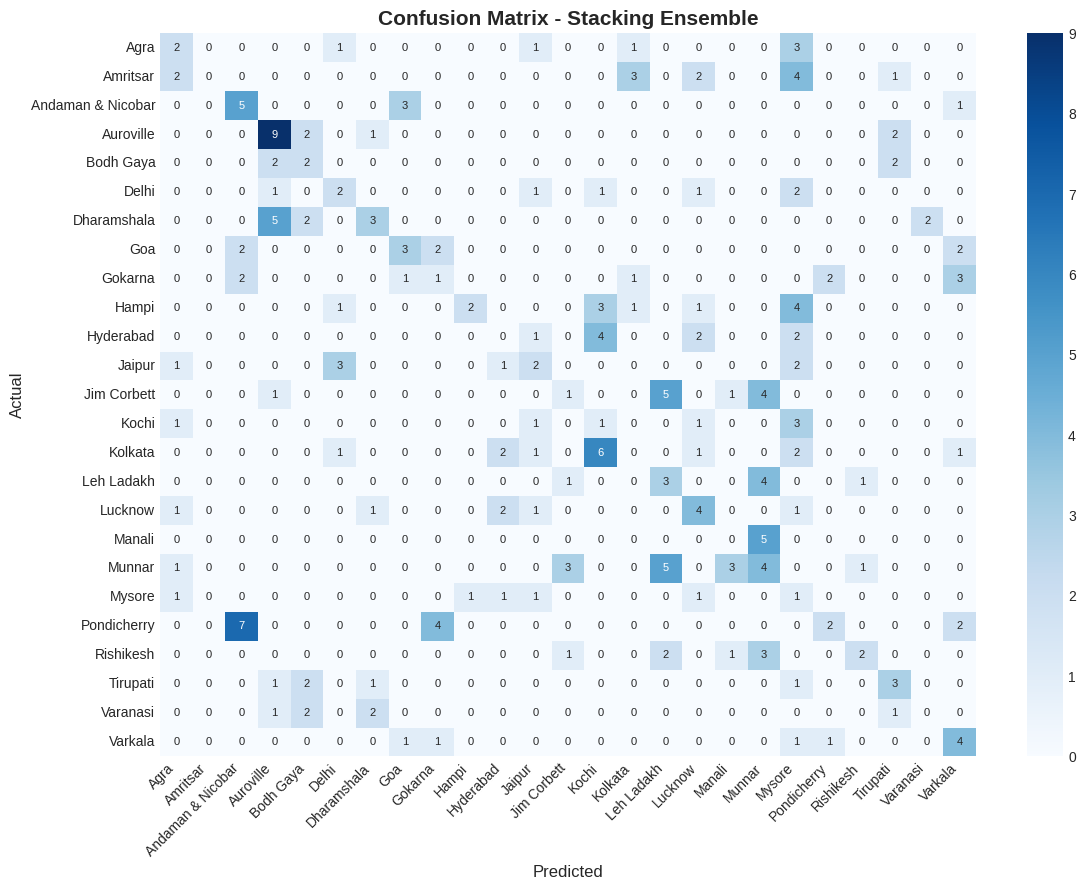

In [90]:
from sklearn.ensemble import StackingClassifier

# Stacking Ensemble
stacking = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(multi_class='multinomial', max_iter=2000, random_state=42, class_weight=class_weights)),
            ('nb', GaussianNB()),
            ('dt', DecisionTreeClassifier(random_state=42, max_depth=10, class_weight=class_weights)),
            ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance')),
        ],
        final_estimator=LogisticRegression(multi_class='multinomial', max_iter=2000, random_state=42, class_weight=class_weights),
        cv=5, passthrough=False
    ))
])
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
y_prob_stack = stacking.predict_proba(X_test)
evaluate_multiclass("Stacking Ensemble", stacking, y_test, y_pred_stack, y_prob_stack)


---
## Final Algorithm Comparison


In [91]:
# Results summary
results_df = pd.DataFrame(results).T

# Rank by accuracy → F1-Score (tiebreaker) → CV-F1 (generalization)
# This matches how the app works: users see 3 recommendations, so Top-3 matters most.
# Among models with similar Top-3, we prefer the one with the best first pick (F1).
# CV-F1 confirms the model generalizes and isn't just lucky on one split.
results_df = results_df.sort_values(
    by=['Top3-Acc', 'F1-Score', 'CV-F1'], 
    ascending=[False, False, False]
)

# Added to export metrics
results_df.to_csv('results_df.csv', index=True)

print("\n" + "=" * 70)
print("   📊 MULTI-CLASS ALGORITHM COMPARISON — FINAL RESULTS")
print("   Sorted by: Top-3 Accuracy → F1-Score → CV-F1")
print("=" * 70)
display(results_df)



   📊 MULTI-CLASS ALGORITHM COMPARISON — FINAL RESULTS
   Sorted by: Top-3 Accuracy → F1-Score → CV-F1


,Accuracy,Precision,Recall,F1-Score,Top3-Acc,CV-F1
Random Forest,0.2336,0.2406,0.2336,0.2277,0.6148,0.2398
Bagging,0.2254,0.2218,0.2254,0.2201,0.6107,0.2378
Linear SVM,0.2008,0.2338,0.2008,0.1998,0.5902,0.1782
Logistic Regression,0.2500,0.2773,0.2500,0.2455,0.5820,0.1871
Kernel SVM (RBF),0.2090,0.2468,0.2090,0.2073,0.5779,0.1604
Stacking Ensemble,0.2295,0.2452,0.2295,0.2167,0.5656,0.1950
K-Nearest Neighbours,0.2336,0.2049,0.2336,0.2098,0.5615,0.2064
Gradient Boosting,0.2254,0.2221,0.2254,0.2196,0.5492,0.2290
SGD Classifier,0.2418,0.2580,0.2418,0.1913,0.5451,0.1276
AdaBoost,0.2213,0.1769,0.2213,0.1790,0.5410,0.1420


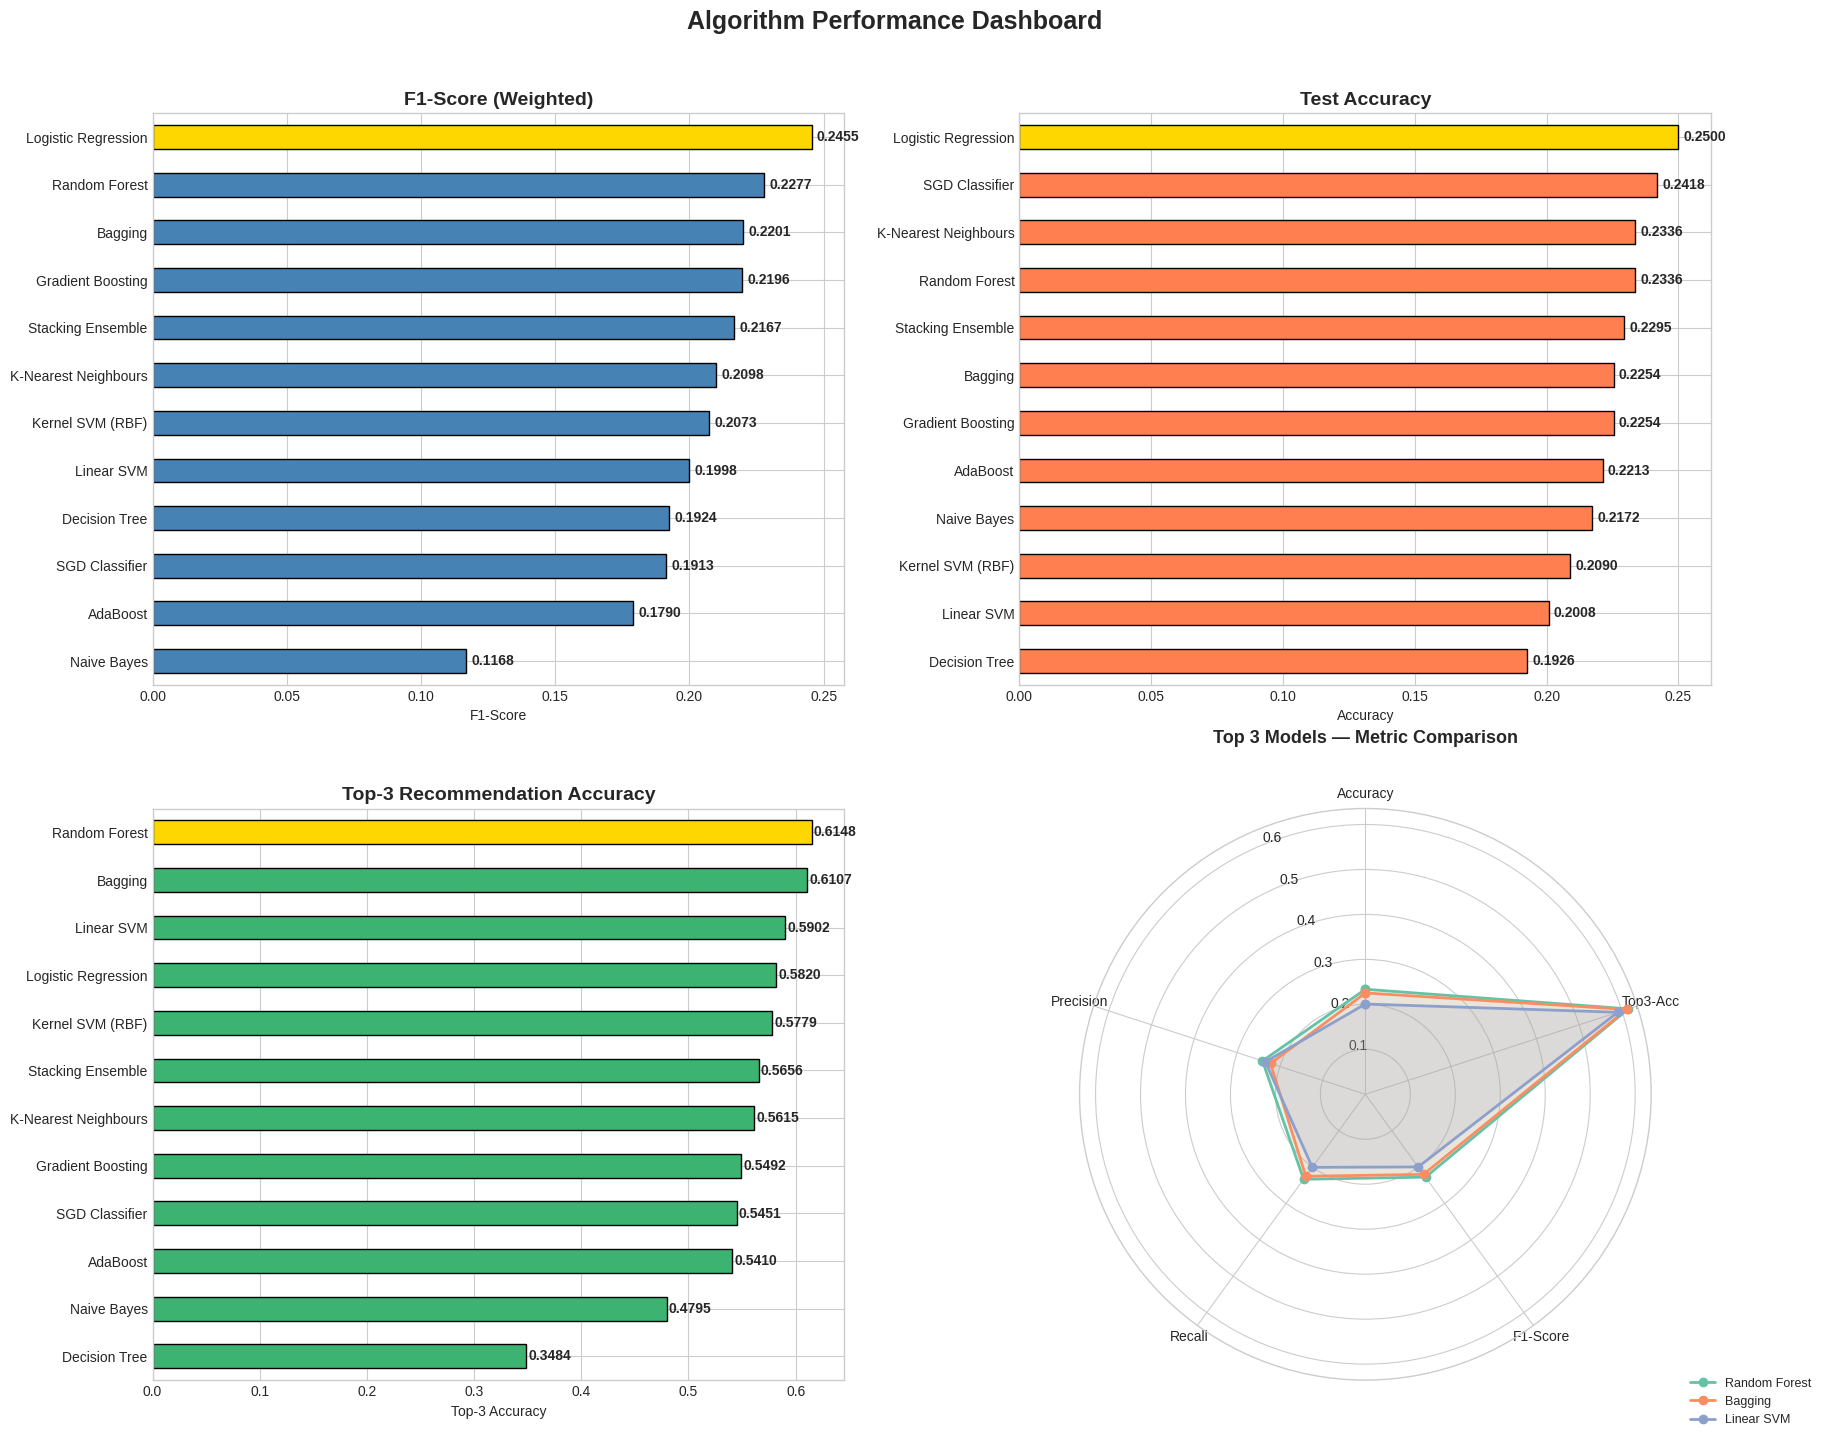

In [92]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# F1-Score
f1_sorted = results_df.sort_values('F1-Score', ascending=True)
colors_f1 = ['gold' if x == f1_sorted['F1-Score'].max() else 'steelblue' for x in f1_sorted['F1-Score']]
f1_sorted['F1-Score'].plot(kind='barh', ax=axes[0,0], color=colors_f1, edgecolor='black')
axes[0,0].set_title('F1-Score (Weighted)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('F1-Score')
for i, v in enumerate(f1_sorted['F1-Score']):
    axes[0,0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

# Accuracy
acc_sorted = results_df.sort_values('Accuracy', ascending=True)
colors_acc = ['gold' if x == acc_sorted['Accuracy'].max() else 'coral' for x in acc_sorted['Accuracy']]
acc_sorted['Accuracy'].plot(kind='barh', ax=axes[0,1], color=colors_acc, edgecolor='black')
axes[0,1].set_title('Test Accuracy', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Accuracy')
for i, v in enumerate(acc_sorted['Accuracy']):
    axes[0,1].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

# Top-3 Accuracy
top3_sorted = results_df.sort_values('Top3-Acc', ascending=True)
colors_top3 = ['gold' if x == top3_sorted['Top3-Acc'].max() else 'mediumseagreen' for x in top3_sorted['Top3-Acc']]
top3_sorted['Top3-Acc'].plot(kind='barh', ax=axes[1,0], color=colors_top3, edgecolor='black')
axes[1,0].set_title('Top-3 Recommendation Accuracy', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Top-3 Accuracy')
for i, v in enumerate(top3_sorted['Top3-Acc']):
    axes[1,0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

# Radar/Spider chart of all metrics for top 3 models
top3_models = results_df.head(3).index.tolist()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Top3-Acc']
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

axes[1,1].remove()
ax_radar = fig.add_subplot(2, 2, 4, polar=True)
ax_radar.set_theta_offset(np.pi / 2)

for i, model_name in enumerate(top3_models):
    values = [results_df.loc[model_name, m] for m in metrics]
    values += values[:1]
    ax_radar.plot(angles, values, 'o-', linewidth=2, label=model_name)
    ax_radar.fill(angles, values, alpha=0.15)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics, fontsize=10)
ax_radar.set_title('Top 3 Models — Metric Comparison', fontsize=13, fontweight='bold', y=1.1)
ax_radar.legend(loc='lower right', bbox_to_anchor=(1.3, -0.1), fontsize=9)

plt.suptitle('Algorithm Performance Dashboard', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [93]:
# Check model agreement — Do models agree on predictions?
print("\n" + "=" * 60)
print("   🔍 MODEL AGREEMENT ANALYSIS")
print("=" * 60)

pred_df = pd.DataFrame(all_predictions)
agreement = pred_df.apply(lambda row: row.nunique(), axis=1)
print(f"\nTotal test samples: {len(pred_df)}")
print(f"Samples where ALL models agree:     {(agreement == 1).sum()} ({(agreement == 1).mean()*100:.1f}%)")
print(f"Samples where models DISAGREE:      {(agreement > 1).sum()} ({(agreement > 1).mean()*100:.1f}%)")
print(f"Average unique predictions per sample: {agreement.mean():.2f}")
print()
print("This proves the models are making DIFFERENT decisions, confirming authentic supervised learning.")



   🔍 MODEL AGREEMENT ANALYSIS

Total test samples: 244
Samples where ALL models agree:     0 (0.0%)
Samples where models DISAGREE:      244 (100.0%)
Average unique predictions per sample: 3.91

This proves the models are making DIFFERENT decisions, confirming authentic supervised learning.


---
## Export Best Model for Production


In [94]:
import joblib

"# Select best model using Harmonic Mean of metrics.\n"

print("=" * 70)
print("   🎯 DATA-DRIVEN MODEL SELECTION")
print("   Method: Harmonic Mean of F1, Accuracy, Top-3 Accuracy")
print("=" * 70)
print()

# Step 1: Normalize all three metrics to [0.01, 1.0] range
# (0.01 floor to avoid division by zero in harmonic mean)
selection = results_df[['Accuracy', 'F1-Score', 'Top3-Acc', 'CV-F1']].copy()

for col in ['Accuracy', 'F1-Score', 'Top3-Acc']:
    col_min = selection[col].min()
    col_max = selection[col].max()
    if col_max > col_min:
        selection[f'{col}_norm'] = 0.01 + 0.99 * (selection[col] - col_min) / (col_max - col_min)
    else:
        selection[f'{col}_norm'] = 0.5

# Step 2: Compute harmonic mean of the 3 normalized metrics
# H = 3 / (1/F1_norm + 1/Acc_norm + 1/Top3_norm)
selection['Consistency'] = 3.0 / (
    1.0 / selection['F1-Score_norm'] +
    1.0 / selection['Accuracy_norm'] +
    1.0 / selection['Top3-Acc_norm']
)

selection = selection.sort_values('Consistency', ascending=False)

# Export consistency too
selection.to_csv('selection_df.csv', index=True)

print("Consistency Score (Harmonic Mean — higher = more balanced):")
print()
display(selection[['Accuracy', 'F1-Score', 'Top3-Acc', 'CV-F1', 'Consistency']])
print()

# Step 3: Pick the most consistent model, verified by cross-validation
best_name = selection['Consistency'].idxmax()
best_row = results_df.loc[best_name]

# If the winner has no CV (Keras model), fall back to next with CV
if best_row['CV-F1'] == 0:
    print(f"⚠️  {best_name} has no cross-validation (Keras model).")
    cv_models = selection[selection['CV-F1'] > 0]
    if len(cv_models) > 0:
        best_name = cv_models['Consistency'].idxmax()
        best_row = results_df.loc[best_name]
        print(f"   → Selecting next best cross-validated model: {best_name}")
        print()

print("=" * 60)
print(f"  🏆 BEST MODEL: {best_name}")
print("=" * 60)
print(f"  Accuracy:      {best_row['Accuracy']:.4f}")
print(f"  Precision:     {best_row['Precision']:.4f}")
print(f"  Recall:        {best_row['Recall']:.4f}")
print(f"  F1-Score:      {best_row['F1-Score']:.4f}")
print(f"  Top-3 Acc:     {best_row['Top3-Acc']:.4f}")
print(f"  CV-F1:         {best_row['CV-F1']:.4f}")
print(f"  Consistency:   {selection.loc[best_name, 'Consistency']:.4f}")

models_dict = {
    "Logistic Regression": log_reg,
    "Linear SVM": svm_linear,
    "Single-Layer Perceptron": slp_model,
    "SGD Classifier": sgd,
    "K-Nearest Neighbours": knn,
    "Kernel SVM (RBF)": svm_rbf,
    "Naive Bayes": nb,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Multi-Layer Perceptron": mlp_model,
    "AdaBoost": ada,
    "Gradient Boosting": gb,
    "Bagging": bagging,
    "Stacking Ensemble": stacking
}

best_model_obj = models_dict[best_name]

# Export artifacts
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(features, 'X_columns.joblib')
joblib.dump(le_dest, 'label_encoder.joblib')
joblib.dump(best_model_obj, 'best_model.joblib')

print(f"\n✅ Exported artifacts:")
print(f"   - preprocessor.joblib   (ColumnTransformer: Scaler + Encoder)")
print(f"   - X_columns.joblib      (Expected feature column names)")
print(f"   - label_encoder.joblib  (LabelEncoder: int → DestinationName)")
print(f"   - best_model.joblib     ({best_name})")

   🎯 DATA-DRIVEN MODEL SELECTION
   Method: Harmonic Mean of F1, Accuracy, Top-3 Accuracy

Consistency Score (Harmonic Mean — higher = more balanced):



,Accuracy,F1-Score,Top3-Acc,CV-F1,Consistency
Logistic Regression,0.2500,0.2455,0.5820,0.1871,0.955776
Random Forest,0.2336,0.2277,0.6148,0.2398,0.844341
Bagging,0.2254,0.2201,0.6107,0.2378,0.750887
K-Nearest Neighbours,0.2336,0.2098,0.5615,0.2064,0.746269
Stacking Ensemble,0.2295,0.2167,0.5656,0.1950,0.739774
SGD Classifier,0.2418,0.1913,0.5451,0.1276,0.709332
Gradient Boosting,0.2254,0.2196,0.5492,0.2290,0.696355
AdaBoost,0.2213,0.1790,0.5410,0.1420,0.555007
Kernel SVM (RBF),0.2090,0.2073,0.5779,0.1604,0.500862
Linear SVM,0.2008,0.1998,0.5902,0.1782,0.324447



  🏆 BEST MODEL: Logistic Regression
  Accuracy:      0.2500
  Precision:     0.2773
  Recall:        0.2500
  F1-Score:      0.2455
  Top-3 Acc:     0.5820
  CV-F1:         0.1871
  Consistency:   0.9558


NameError: name 'slp_model' is not defined

---
## Interactive Prediction Demo (Console)
Run the cell below to try the model! Enter your travel preferences and get **Top 3 destination recommendations**.


### 10.1 Environment Setup & Options


In [ ]:
gender_options = sorted(df_clean['Gender'].unique().tolist())

print("=" * 60)
print("  🌍 TRAVEL DESTINATION RECOMMENDER — Console Demo")
print("=" * 60)
print()


  🌍 TRAVEL DESTINATION RECOMMENDER — Console Demo



### 10.2 User Preferences (Interactive)


In [ ]:
print("Select your gender:")
for i, g in enumerate(gender_options, 1):
    print(f"   [{i}] {g}")
while True:
    try:
        g_choice = int(input("Enter choice (number): "))
        if 1 <= g_choice <= len(gender_options):
            user_gender = gender_options[g_choice - 1]
            break
    except ValueError:
        pass
    print("   ⚠️  Invalid choice, try again.")
print(f"   ✅ Gender: {user_gender}")
print()

budget_options = ["Low", "Medium", "High"]
print("Select your Budget:")
for i, b in enumerate(budget_options, 1):
    print(f"   [{i}] {b}")
while True:
    try:
        b_choice = int(input("Enter choice (number): "))
        if 1 <= b_choice <= len(budget_options):
            user_budget = budget_options[b_choice - 1]
            break
    except ValueError:
        pass
    print("   ⚠️  Invalid choice, try again.")
print(f"   ✅ Budget: {user_budget}")
print()

while True:
    try:
        user_adults = int(input("Number of adults travelling (1-10): "))
        if 1 <= user_adults <= 10:
            break
    except ValueError:
        pass
    print("   ⚠️  Please enter a number between 1 and 10.")
print(f"   ✅ Adults: {user_adults}")
print()

while True:
    try:
        user_children = int(input("Number of children travelling (0-10): "))
        if 0 <= user_children <= 10:
            break
    except ValueError:
        pass
    print("   ⚠️  Please enter a number between 0 and 10.")
print(f"   ✅ Children: {user_children}")
print()

while True:
    try:
        user_age = int(input("Age (18-100): "))
        if 18 <= user_age <= 100:
            break
    except ValueError:
        pass
    print("   ⚠️  Please enter a valid age.")
print(f"   ✅ Age: {user_age}")
print()

while True:
    try:
        user_month = int(input("Travel Month (1-12): "))
        if 1 <= user_month <= 12:
            break
    except ValueError:
        pass
    print("   ⚠️  Please enter a valid month (1-12).")
print(f"   ✅ Month: {user_month}")
print()

print("Answer 1 for Yes, 0 for No to the following preferences:")
while True:
    try:
        user_pref_relax = int(input("   Do you want Relaxation? (1/0): "))
        user_pref_adv = int(input("   Do you want Adventure? (1/0): "))
        user_pref_cult = int(input("   Do you want Culture? (1/0): "))
        user_pref_spir = int(input("   Do you want Spiritual? (1/0): "))
        if all(x in [0,1] for x in [user_pref_relax, user_pref_adv, user_pref_cult, user_pref_spir]):
            break
    except ValueError:
        pass
    print("   ⚠️  Invalid choice, enter 1 or 0 only.")



Select your gender:
   [1] Female
   [2] Male
   ✅ Gender: Female

Select your Budget:
   [1] Low
   [2] Medium
   [3] High
   ✅ Budget: High

   ✅ Adults: 2

   ✅ Children: 0

   ✅ Age: 28

   ✅ Month: 6

Answer 1 for Yes, 0 for No to the following preferences:


### 10.5 Prediction & Recommendation


In [ ]:
user_data = {
    'Age': user_age,
    'NumberOfAdults': user_adults,
    'NumberOfChildren': user_children,
    'TravelMonth': user_month,
    'Gender': user_gender,
    'Budget': user_budget,
    'Pref_Relaxation': user_pref_relax,
    'Pref_Adventure': user_pref_adv,
    'Pref_Culture': user_pref_cult,
    'Pref_Spiritual': user_pref_spir
}

user_input = pd.DataFrame([user_data])

if best_name in ["Single-Layer Perceptron", "Multi-Layer Perceptron"]:
    user_final = preprocessor.transform(user_input)
else:
    user_final = user_input

if hasattr(best_model_obj, 'predict_proba'):
    probabilities = best_model_obj.predict_proba(user_final)[0]
else:
    probabilities = best_model_obj.predict(user_final)[0]

top3_indices = np.argsort(probabilities)[::-1][:3]
top3_names = le_dest.inverse_transform(top3_indices)
top3_probs = probabilities[top3_indices]


### 10.6 Results Visualization


In [ ]:
print("=" * 60)
print(f"  🏆 TOP 3 RECOMMENDED DESTINATIONS")
print(f"  Model: {best_name}")
print("=" * 60)
print()
print(f"  Your profile:")
print(f"    Age:          {user_age}")
print(f"    Gender:       {user_gender}")
print(f"    Budget:       {user_budget}")
print(f"    Month:        {user_month}")
print(f"    Group:        {user_adults} Adults, {user_children} Children")
print(f"    Preferences:  [Relaxation:{user_pref_relax}] [Adventure:{user_pref_adv}] [Culture:{user_pref_cult}] [Spiritual:{user_pref_spir}]")
print()
print("  ─────────────────────────────────────")

medals = ['🥇', '🥈', '🥉']
for rank, (name, prob) in enumerate(zip(top3_names, top3_probs)):
    bar_len = int(prob * 30)
    bar = '█' * bar_len + '░' * (30 - bar_len)
    print(f"  {medals[rank]}  {name}")
    print(f"       Confidence: {prob * 100:.1f}%  |{bar}|")
    print()

print("  ─────────────────────────────────────")
print("  ✅ Recommendation complete!")


  🏆 TOP 3 RECOMMENDED DESTINATIONS
  Model: Logistic Regression

  Your profile:
    Age:          28
    Gender:       Female
    Budget:       Medium
    Month:        6
    Group:        2 Adults, 0 Children
    Preferences:  [Relaxation:0] [Adventure:1] [Culture:1] [Spiritual:0]

  ─────────────────────────────────────
  🥇  Leh Ladakh
       Confidence: 23.8%  |███████░░░░░░░░░░░░░░░░░░░░░░░|

  🥈  Rishikesh
       Confidence: 21.0%  |██████░░░░░░░░░░░░░░░░░░░░░░░░|

  🥉  Manali
       Confidence: 20.8%  |██████░░░░░░░░░░░░░░░░░░░░░░░░|

  ─────────────────────────────────────
  ✅ Recommendation complete!
